<a href="https://colab.research.google.com/github/joshstructure/D2MPDB/blob/main/Bridge_Geometry_2%20Beam_V2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bridge_Geometry_2 Beam_V2

Two-beam bridge geometry with coordinated project inputs.

[Open this notebook in Colab](https://colab.research.google.com/github/joshstructure/D2MPDB/blob/main/Bridge_Geometry_2%20Beam_V2.ipynb)

Updated 29 September 2026: Type F bearings (2-9/16 in thick, 32 in wide),
6-in-high × 42-in-wide pedestals, and a **36-in-deep cap**.
The transverse cap length is derived from **four 20-in piles at 3D = 5-ft centers**
and **15-in clear from each end pile face to the cap end**: **19 ft 2 in**.
Cap longitudinal width remains 4 ft. The adopted 15-in geometric clearance includes no added tolerance extension.

The normal slab is **13 ft 7 in wide × 6 in thick**, area **6.7916667 ft²**.
Haunch concrete is a separate integrated quantity; it is not included in that slab area.
The corresponding updated Journal 32 uses these notebook geometry and quantity inputs.

Updated 9 October 2026: **12-in pile embedment** gives cutoff elevations in the pier
schedule, longitudinal elevations plot and transverse pier section. The roadway XML
loads from this GitHub repository automatically; Google Drive is not required.

End Bent 1 and End Bent 2 now have full elevation views and schedules using the
accepted 8 October project cap/pile geometry. A large minimum-clearance readout and
dimension arrow identify the governing roadway station and beam(s).

Run All after editing Section 1. Saved figures and tables are a snapshot of those inputs.
Live controls rebuild all dashboard results together; rerun to refresh the saved snapshot.


## 1. Inputs and source assumptions

Deck width 13 ft 7 in, beam spacing 8 ft 7 in, normal slab 6 in and two FIB36 beams follow
the current two-beam geometry. Pad and pedestal dimensions follow the adopted Type F project data.
The cap depth and pile arrangement implement the user's 29 September 2026 update.

Cap length = (pile count − 1) × spacing + pile diameter + 2 × pile-face end clearance.
Pile centers are measured transversely from cap center. A 15-in face clearance gives 25 in
from the outer pile centerline to the cap end. These are geometric dimensions, not a pile-cap capacity check.

The profile, 1-in span cambers, 2% crown and 0.5-in minimum flange-edge haunch retain the notebook basis.
The pier station 17+00.57 remains an idealized common support. Physical bearing rows lie 10.5 in
either side of pier CL; end-bearing station relationships remain to be established before setting out seats.

Pile cutoff = cap top at each pile centerline − cap depth + embedment / 12.
Embedment defaults to 12 in and is measured vertically above the local underside.
End-bent geometry follows `BridgeGeometry_2Beam` in the accepted project journal
(8 October 2026): 212-in length, 42-in width, 36-in depth; four 18-in square piles at
54-in centers, 25-in end center distances, and 12-in pile embedment. The end-bent
pedestals are 6 in high × 42 in transverse × 30 in longitudinal, with Type F bearings.
Both ends share these dimensions but calculate their own elevations. The 12-in
backwall thickness is known; its height and the cheek-wall geometry remain undefined.
Their elevation outlines are therefore not included.

End-bent sections use the notebook's idealized begin/end support stations. The
recorded bearing offset is 3 in toward the span from cap/pile CL. This offset is
reported as a local layout dimension; it does not shift the existing beam chord or
claim a surveyed bearing/cap station relationship.

`Geometry Report.xml` is the only external elevation file. Keep it beside the notebook
for local/offline use. A fresh Colab session fetches the versioned GitHub copy without
mounting Drive or requesting Google account access. Custom XML paths remain supported.

Roadway XML zero maps to bridge station 15+93.22 as the existing assumption. Coverage gaps are
not extrapolated. Local deck-end thickening is outside the uniform slab/haunch model and must be
accounted for separately once its detail is resolved. Pile layout changes require corresponding analysis forces.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML
plt.rcParams.update({'font.size': 10, 'figure.dpi': 110})


In [2]:
# @title Project inputs — edit here, then Run All
# Feet unless a key ends in _in. Grade/slope inputs are ft/ft.
# Deck width is independent of beam spacing: 13 ft 7 in from DXF *D5380.
# Type F pads: 10 in longitudinal x 32 in transverse x 2-9/16 in thick.
# Cap depth 36 in; four 20-in piles at 3D centers; 15-in clear beyond each outer pile face.
# Pier length_ft=None derives 19 ft 2 in from that layout; 4-ft cap width is retained.
# Scalar beam/pedestal inputs apply to all beams; lists must match the beam count.
# Parabola preserves both endpoint elevations and grade change; entering grade is derived.
# Transition is a uniform slope varying with station (not an implied crown-unfolding model).
CONFIG = {'profile': {'mode': 'brokeback',
             'start_sta_ft': 1593.22,
             'end_sta_ft': 1805.47,
             'start_elev_ft': 47.661,
             'end_elev_ft': 47.673,
             'intersection_sta_ft': 1700.57,
             'nominal_grade': 0.005,
             'parabolic_grade_change': -0.01},
 'deck': {'mode': 'crowned',
          'width_ft': 13.583333333333334,
          'center_offset_ft': 0.0,
          'thickness_ft': 0.5,
          'crown_slope': -0.02,
          'uniform_slope': -0.02,
          'transition_start_ft': 1603.22,
          'transition_end_ft': 1643.22,
          'slope_start': -0.02,
          'slope_end': 0.04},
 'beams': {'count': 2,
           'spacing_ft': 8 + 7/12,
           'first_offset_ft': None,
           'gaps_ft': None,
           'raise_in': 0.0,
           'depth_ft': 3,
           'top_flange_width_in': 48.0,
           'minimum_haunch_in': 0.5},
 'spans': [{'id': 1, 'start_ft': 1593.22, 'end_ft': 1700.57, 'camber_in': 1.0},
           {'id': 2, 'start_ft': 1700.57, 'end_ft': 1805.47, 'camber_in': 1.0}],
 'roadway': {'xml_path': 'Geometry Report.xml',
             'alignment_name': 'Unnamed',
             'bridge_station_at_xml_zero_ft': np.float64(1593.22),
             'clearance_required_ft': 17.0},
 'pier': {'station_ft': 1700.57,
          'pad_height_in': 2 + 9/16,
          'depth_ft': 3,
          'length_ft': None,  # Derived from the pile layout below; no independent cap length.
          'width_ft': 4,
          'pile_count': 4,
          'pile_diameter_in': 20,
          'pile_embedment_in': 12.0,  # Vertical embedment above cap underside at each pile CL.
          'pile_spacing_diameters': 3,
          'pile_end_clear_in': 15,
          'minimum_pedestal_cl_in': 6,
          'top_center_ft': None,
          'center_offset_ft': 0.0,
          'cross_slope': 0.0,
          'pedestal_width_in': 42.0,
          'pad_width_in': 32.0},
 'evaluation': {'points_per_span': 121}}

# End-bent basis: accepted project journal, BridgeGeometry_2Beam, 8 Oct 2026.
# Journal SHA256: 99e0daa0d7b80581d780152aabc71b85928f8978b768a5fa01173ef9c6ed29c0
# 212-in cap length = 3 x 54-in pile spaces + 2 x 25-in end-center distances.
# Square pile face clearance = 9-in edge clearance + 3-in tolerance + 4-in detail.
# Both end bents share the recorded configuration; their elevations are calculated separately.
END_BENT_DEFAULTS = {
    'width_ft': 42/12, 'depth_ft': 36/12, 'length_ft': None,
    'pile_count': 4, 'pile_width_in': 18.0, 'pile_spacing_in': 54.0,
    'pile_end_clear_in': 16.0, 'pile_embedment_in': 12.0,
    'pad_height_in': 2 + 9/16, 'pad_width_in': 32.0, 'pad_length_in': 10.0,
    'minimum_pedestal_cl_in': 6.0, 'pedestal_width_in': 42.0,
    'top_center_ft': None, 'center_offset_ft': 0.0, 'cross_slope': 0.0,
    'backwall_thickness_in': 12.0, 'rear_face_inset_in': 0.0,
    'beam_end_clear_in': 3.0, 'beam_end_to_bearing_in': 9.0,
}
# Independent copies: edits to one end bent do not change the pier or the other end.
CONFIG['end_bents'] = {
    'start': dict(END_BENT_DEFAULTS),
    'end': dict(END_BENT_DEFAULTS),
}

# The only external elevation input is versioned with this notebook on GitHub.
# Use the adjacent file locally; a fresh Colab runtime downloads the same XML.
# An explicitly entered custom path is never replaced by the default data.
from urllib.request import urlopen
import xml.etree.ElementTree as ET

ROADWAY_DATA_URL = (
    'https://raw.githubusercontent.com/joshstructure/D2MPDB/'
    'a83c357a0115f2289439135081e320215f9c1f88/Geometry%20Report.xml'
)

def ensure_roadway_file(path):
    path = Path(path)
    if path.is_file():
        return path
    if path != Path('Geometry Report.xml'):
        raise FileNotFoundError(f'Roadway XML not found: {path}. Supply that file or use Geometry Report.xml.')
    try:
        with urlopen(ROADWAY_DATA_URL, timeout=30) as response:
            data = response.read()
        root = ET.fromstring(data)
        if not any(node.tag.split('}')[-1] == 'VerticalAlignment' for node in root.iter()):
            raise ValueError('Downloaded XML has no vertical alignment.')
    except Exception as error:
        raise RuntimeError(
            'Could not load roadway elevations from GitHub. Retry with internet access, '
            'or download Geometry Report.xml from the repository beside this notebook.'
        ) from error
    # Save only after the complete response has passed XML validation.
    path.write_bytes(data)
    return path

CONFIG['roadway']['xml_path'] = str(ensure_roadway_file(CONFIG['roadway']['xml_path']))


## 2. Shared geometry and validation

One model feeds every table and drawing. Inputs are validated before the result snapshot is built.
Beam supports follow the profile chord with one bridge-wide downward offset, chosen to satisfy the
minimum haunch across **all spans and all flange locations**, including quadratic extrema.
This can lower beams when you change camber/profile/slope; the resulting clearance is always rechecked.

Profile modes: **brokeback** uses the original balanced tangent construction; **parabolic** preserves both
endpoint elevations and the entered grade change. Deck transition is a station-dependent **uniform** slope;
it is not a preview-only checkbox and does not imply an unmodeled crown-unfolding design.

The functions are folded for reading convenience, but remain fully inside this notebook.


In [3]:
# @title
import copy
import hashlib
import json
import xml.etree.ElementTree as ET
from pathlib import Path
import numpy as np
import pandas as pd


def station_label(value):
    sign = '-' if value < 0 else ''
    hundredths = round(abs(float(value)) * 100)
    return f'{sign}{hundredths // 10000}+{(hundredths % 10000)/100:05.2f}'


def finite(value, name, positive=False):
    if isinstance(value, (bool, np.bool_)) or not np.isscalar(value):
        raise ValueError(f'{name}: enter a finite number.')
    value = float(value)
    if not np.isfinite(value) or (positive and value <= 0):
        raise ValueError(f'{name}: enter a {"positive " if positive else ""}finite number.')
    return value


def beam_values(value, n, name, positive=False):
    a = np.asarray(value, dtype=float)
    if a.ndim == 0:
        a = np.full(n, float(a))
    if a.shape != (n,) or not np.all(np.isfinite(a)) or (positive and np.any(a <= 0)):
        raise ValueError(f'{name}: enter one finite {"positive " if positive else ""}value or exactly {n} values.')
    return a


def configuration_id(config):
    return hashlib.sha256(json.dumps(config, sort_keys=True).encode()).hexdigest()[:10]


class BridgeModel:
    """One resolved geometry model; tables and figures only consume its results.

    Feet internally; inputs explicitly labeled _in are converted once. Span
    camber is an upward quadratic, and supports share one vertical translation.
    XML station mapping is an explicit project assumption, not inferred survey geometry.
    """
    def __init__(self, config):
        self.cfg = copy.deepcopy(config)
        self.model_id = configuration_id(config)
        p, d, b = self.cfg['profile'], self.cfg['deck'], self.cfg['beams']
        self.start = finite(p['start_sta_ft'], 'Profile start')
        self.end = finite(p['end_sta_ft'], 'Profile end')
        if self.end <= self.start:
            raise ValueError('Profile end must follow its start.')
        self.z0 = finite(p['start_elev_ft'], 'Profile start elevation')
        self.z1 = finite(p['end_elev_ft'], 'Profile end elevation')
        self.peak = finite(p['intersection_sta_ft'], 'Tangent intersection station')
        if not self.start < self.peak < self.end:
            raise ValueError('Tangent intersection must be inside the profile.')
        self.profile_mode = p['mode']
        length = self.end-self.start
        if self.profile_mode == 'brokeback':
            magnitude = finite(p['nominal_grade'], 'Nominal tangent grade', True)
            self.peak_elev = (self.z0+magnitude*(self.peak-self.start)
                              +self.z1+magnitude*(self.end-self.peak))/2
            self.g1 = (self.peak_elev-self.z0)/(self.peak-self.start)
            self.g2 = (self.z1-self.peak_elev)/(self.end-self.peak)
        elif self.profile_mode == 'parabolic':
            delta = finite(p['parabolic_grade_change'], 'Parabolic grade change')
            # Endpoint elevations and grade change govern; entering grade is derived.
            self.g1 = (self.z1-self.z0)/length-delta/2
            self.g2 = self.g1+delta
        else:
            raise ValueError('Profile mode must be brokeback or parabolic.')
        self.deck_width = finite(d['width_ft'], 'Deck width', True)
        self.deck_center = finite(d['center_offset_ft'], 'Deck center offset')
        self.deck_thickness = finite(d['thickness_ft'], 'Deck thickness', True)
        self.deck_mode = d['mode']
        for name in ['crown_slope','uniform_slope','transition_start_ft','transition_end_ft','slope_start','slope_end']:
            finite(d[name], name)
        if self.deck_mode not in ['crowned','uniform','transition']:
            raise ValueError('Deck mode must be crowned, uniform, or transition.')
        if self.deck_mode == 'transition' and d['transition_end_ft'] <= d['transition_start_ft']:
            raise ValueError('Slope transition end must follow its start.')
        self.count = b['count']
        if isinstance(self.count,bool) or not isinstance(self.count,int) or self.count < 1:
            raise ValueError('Beam count must be a positive integer.')
        if b['gaps_ft'] is None:
            gaps = np.full(self.count-1, finite(b['spacing_ft'],'Beam spacing',True))
        else:
            gaps = np.asarray(b['gaps_ft'],dtype=float)
            if gaps.shape != (self.count-1,) or not np.all(np.isfinite(gaps)) or np.any(gaps<=0):
                raise ValueError('Unequal gaps require count-1 positive finite values.')
        self.offsets = np.r_[0.,np.cumsum(gaps)]
        self.offsets += (-self.offsets[-1]/2 if b['first_offset_ft'] is None
                         else finite(b['first_offset_ft'],'First beam offset'))
        self.raises = beam_values(b['raise_in'],self.count,'Beam vertical offsets')/12
        self.depth = finite(b['depth_ft'],'Beam depth',True)
        self.flange = finite(b['top_flange_width_in'],'Top flange width',True)/12
        self.minimum_haunch = finite(b['minimum_haunch_in'],'Minimum haunch')/12
        if self.minimum_haunch < 0 or np.any(gaps < self.flange-1e-9):
            raise ValueError('Minimum haunch must be nonnegative and beam flanges must not overlap.')
        self.deck_left = self.deck_center-self.deck_width/2
        self.deck_right = self.deck_center+self.deck_width/2
        if self.offsets[0]-self.flange/2 < self.deck_left-1e-9 or self.offsets[-1]+self.flange/2 > self.deck_right+1e-9:
            raise ValueError('Beam flanges extend outside the entered deck width.')
        self.spans = pd.DataFrame(self.cfg['spans']).sort_values('start_ft').reset_index(drop=True)
        if len(self.spans)<1 or self.spans['id'].duplicated().any():
            raise ValueError('Provide spans with unique IDs.')
        for name in ['start_ft','end_ft','camber_in']:
            if not np.all(np.isfinite(self.spans[name].to_numpy(dtype=float))):
                raise ValueError('Span inputs must be finite.')
        self.spans['length_ft'] = self.spans['end_ft']-self.spans['start_ft']
        if np.any(self.spans['length_ft']<=0) or np.any(self.spans['camber_in']<0):
            raise ValueError('Span lengths must be positive and camber cannot be negative.')
        if not np.allclose(self.spans['end_ft'].to_numpy()[:-1],self.spans['start_ft'].to_numpy()[1:],rtol=0,atol=1e-8):
            raise ValueError('Spans must meet without gaps or overlaps.')
        if not np.isclose(self.spans.iloc[0].start_ft,self.start,rtol=0,atol=1e-8) or not np.isclose(self.spans.iloc[-1].end_ft,self.end,rtol=0,atol=1e-8):
            raise ValueError('Spans must cover the entered profile limits.')
        self.clearance_required = finite(self.cfg['roadway']['clearance_required_ft'],'Required clearance',True)
        points = self.cfg['evaluation']['points_per_span']
        if isinstance(points,bool) or not isinstance(points,int) or points<5:
            raise ValueError('points_per_span must be an integer of at least 5.')
        self.road, self.road_note = self.load_roadway()
        # Find every quadratic extremum, not just the stations of a sampling grid.
        self.haunch_candidates = [self.critical_stations(i, self.uncorrected_haunch) for i in range(len(self.spans))]
        worst = min(np.min(self.uncorrected_haunch(s,i)) for i,s in enumerate(self.haunch_candidates))
        self.support_drop = self.minimum_haunch-worst
        self.spans['bottom_start_ft'] = self.pgl(self.spans.start_ft.to_numpy())-self.support_drop
        self.spans['bottom_end_ft'] = self.pgl(self.spans.end_ft.to_numpy())-self.support_drop
        self.clearance_candidates = [self.critical_stations(i,lambda s,j:self.evaluate(s,j)['clearance'])
                                     for i in range(len(self.spans))]
        grids=[]
        for i,row in self.spans.iterrows():
            grids.append(np.unique(np.r_[np.linspace(row.start_ft,row.end_ft,points),self.breakpoints(i),
                                          self.haunch_candidates[i],self.clearance_candidates[i],
                                          (row.start_ft+row.end_ft)/2]))
        self.stations = np.unique(np.concatenate(grids))
        self.results = self.evaluate(self.stations)
        self.haunch_min, self.haunch_station, self.haunch_beam = self.minimum('haunch')
        self.clearance_min, self.clearance_station, self.clearance_beam = self.minimum('clearance')
        self.covered_length = sum(max(0,min(r['end'],self.end)-max(r['start'],self.start)) for r in self.road)
        self.full_road_coverage = abs(self.covered_length-(self.end-self.start)) <= 1e-6
        self.quantity_table = self.quantities()
        self.pier = self.pier_geometry()
        self.end_bents = self.end_bent_geometries()
        self.supports = [self.pier] + self.end_bents

    def pgl(self, stations):
        s=np.asarray(stations,dtype=float)
        if self.profile_mode=='brokeback':
            return np.where(s<=self.peak,self.z0+self.g1*(s-self.start),self.peak_elev+self.g2*(s-self.peak))
        x=s-self.start
        return self.z0+self.g1*x+.5*(self.g2-self.g1)/(self.end-self.start)*x*x

    def deck_delta(self, stations, offsets):
        s,x=np.broadcast_arrays(np.asarray(stations,dtype=float),np.asarray(offsets,dtype=float))
        d=self.cfg['deck']
        if self.deck_mode=='crowned': return np.abs(x)*d['crown_slope']
        slope=(d['uniform_slope'] if self.deck_mode=='uniform' else
               np.interp(s,[d['transition_start_ft'],d['transition_end_ft']],[d['slope_start'],d['slope_end']]))
        return x*slope

    def deck_top(self, stations, offsets):
        return self.pgl(stations)+self.deck_delta(stations,offsets)

    def span_components(self, stations, span_index=None):
        s=np.atleast_1d(np.asarray(stations,dtype=float))
        if not np.all(np.isfinite(s)) or np.any(s<self.start-1e-8) or np.any(s>self.end+1e-8):
            raise ValueError('Station is outside the bridge.')
        if span_index is None:
            # Interior support belongs to the departing span; final support to last span.
            index=np.minimum(np.searchsorted(self.spans.end_ft.to_numpy(),s,side='right'),len(self.spans)-1)
        else:
            index=np.full(s.shape,int(span_index))
        a=self.spans.start_ft.to_numpy()[index];L=self.spans.length_ft.to_numpy()[index]
        if np.any(s<a-1e-8) or np.any(s>a+L+1e-8): raise ValueError('Station does not belong to selected span.')
        t=(s-a)/L
        chord=self.pgl(a)+(self.pgl(a+L)-self.pgl(a))*t
        camber=4*self.spans.camber_in.to_numpy()[index]/12*t*(1-t)
        return index,chord,camber

    def flange_offsets(self):
        x=self.offsets[:,None]+np.array([-self.flange/2,0,self.flange/2])
        # The fourth point captures a crown break even when it is not at beam CL.
        return np.c_[x,np.clip(np.zeros(self.count),x[:,0],x[:,-1])]

    def uncorrected_haunch(self, stations, span_index):
        s=np.atleast_1d(stations);_,chord,camber=self.span_components(s,span_index)
        x=self.flange_offsets()
        return self.deck_top(s[:,None,None],x[None,:,:])-self.deck_thickness-(
            chord[:,None,None]+camber[:,None,None]+self.raises[None,:,None]+self.depth)

    def breakpoints(self, span_index):
        row=self.spans.iloc[span_index];points=[row.start_ft,row.end_ft]
        if self.profile_mode=='brokeback':points.append(self.peak)
        elif abs(self.g2-self.g1)>1e-14:
            points.append(self.start-self.g1*(self.end-self.start)/(self.g2-self.g1))
        if self.deck_mode=='transition':points.extend([self.cfg['deck']['transition_start_ft'],self.cfg['deck']['transition_end_ft']])
        for segment in self.road:points.extend([segment['start'],segment['end']])
        return np.unique([float(p) for p in points if row.start_ft<=p<=row.end_ft])

    def critical_stations(self, span_index, function):
        cuts=self.breakpoints(span_index);points=list(cuts)
        for a,b in zip(cuts[:-1],cuts[1:]):
            y=np.asarray(function(np.array([a,(a+b)/2,b]),span_index)).reshape(3,-1)
            # y(t) = A*t^2+B*t+C, t in [0,1], exact within each modeled interval.
            A=2*(y[2]-2*y[1]+y[0]);B=y[2]-y[0]-A
            with np.errstate(divide='ignore',invalid='ignore'): roots=-B/(2*A)
            valid=np.isfinite(roots)&(np.abs(A)>1e-12)&(roots>0)&(roots<1)
            points.extend(a+(b-a)*roots[valid])
        return np.unique(points)

    def load_roadway(self):
        cfg=self.cfg['roadway'];path=Path(cfg['xml_path'])
        if not path.exists():return [],f'XML not found: {path}. Clearance not evaluated.'
        try:
            root=ET.parse(path).getroot()
            # Strip namespaces while retaining source element names.
            for node in root.iter():node.tag=node.tag.split('}')[-1]
            alignments=list(root.iter('VerticalAlignment'))
            name=cfg['alignment_name']
            choices=[a for a in alignments if a.get('name')==name] if name is not None else alignments
            if len(choices)!=1:raise ValueError('Select one unique XML vertical alignment by name.')
            shift=finite(cfg['bridge_station_at_xml_zero_ft'],'XML station mapping')
            def point(e):return float(e.find('station').get('externalStation'))+shift,float(e.get('elevation'))
            segments=[]
            for elements in choices[0].iter('VerticalElements'):
                for e in elements:
                    if e.tag not in ['VerticalLine','VerticalParabola']:raise ValueError(f'Unsupported roadway element: {e.tag}')
                    a,z0=point(e.find('VerticalStart'));b,z1=point(e.find('VerticalEnd'));L=b-a
                    if L<=0:raise ValueError('Roadway elements must have positive length.')
                    grade=(z1-z0)/L;quad=0.
                    if e.tag=='VerticalParabola':
                        pi,zi=point(e.find('VerticalPI'))
                        if not a<pi<b:raise ValueError('Invalid roadway VPI station.')
                        grade=(zi-z0)/(pi-a);g2=(z1-zi)/(b-pi);quad=(g2-grade)/(2*L)
                        if abs(z0+grade*L+quad*L*L-z1)>.001:raise ValueError('Roadway parabola endpoint is inconsistent.')
                    if not np.all(np.isfinite([a,b,z0,grade,quad])):raise ValueError('Nonfinite roadway data.')
                    segments.append(dict(start=a,end=b,z=z0,g=grade,q=quad))
            segments.sort(key=lambda r:r['start'])
            if not segments:raise ValueError('No roadway segments found.')
            for a,b in zip(segments[:-1],segments[1:]):
                if b['start']<a['end']-1e-6:raise ValueError('Overlapping roadway segments.')
                if abs(b['start']-a['end'])<1e-6:
                    z=a['z']+a['g']*(a['end']-a['start'])+a['q']*(a['end']-a['start'])**2
                    if abs(z-b['z'])>.001:raise ValueError('Discontinuous roadway segment elevations.')
            return segments,f"Alignment {choices[0].get('name','(unnamed)')}; no extrapolation."
        except (ET.ParseError,OSError,ValueError,AttributeError,TypeError) as error:
            return [],f'Roadway unavailable: {error}'

    def roadway(self, stations):
        s=np.atleast_1d(np.asarray(stations,dtype=float));out=np.full(s.shape,np.nan)
        for row in self.road:
            mask=(s>=row['start']-1e-9)&(s<=row['end']+1e-9);x=s[mask]-row['start']
            out[mask]=row['z']+row['g']*x+row['q']*x*x
        return out

    def evaluate(self, stations, span_index=None):
        s=np.atleast_1d(np.asarray(stations,dtype=float));idx,chord,camber=self.span_components(s,span_index)
        bottom=chord[:,None]-self.support_drop+camber[:,None]+self.raises[None,:]
        top=bottom+self.depth
        deck=self.deck_top(s[:,None,None],self.flange_offsets()[None,:,:])
        road=self.roadway(s)
        return dict(station=s,span=idx,pgl=self.pgl(s),camber=camber,bottom=bottom,top=top,deck=deck,
                    haunch=deck-self.deck_thickness-top[:,:,None],roadway=road,
                    clearance=bottom-road[:,None])

    def minimum(self, kind):
        best=(np.inf,np.nan,None)
        candidates=self.haunch_candidates if kind=='haunch' else self.clearance_candidates
        for i,s in enumerate(candidates):
            values=(self.uncorrected_haunch(s,i)+self.support_drop if kind=='haunch'
                    else self.evaluate(s,i)['clearance'])
            if not np.any(np.isfinite(values)):continue
            index=np.unravel_index(np.nanargmin(values),values.shape)
            if values[index]<best[0]:best=(float(values[index]),float(s[index[0]]),index[1]+1)
        return best if np.isfinite(best[0]) else (np.nan,np.nan,None)

    def flange_area(self, station, beam, span):
        row=self.evaluate([station],span)
        left,right=self.offsets[beam]+np.array([-self.flange/2,self.flange/2])
        xs=np.unique([left,right]+([0.] if left<0<right else []))
        h=self.deck_top(station,xs)-self.deck_thickness-row['top'][0,beam]
        return float(np.trapezoid(h,xs))

    def quantities(self):
        rows=[]
        for i,span in self.spans.iterrows():
            cuts=self.breakpoints(i)
            hs=self.uncorrected_haunch(self.haunch_candidates[i],i)+self.support_drop
            for b in range(self.count):
                volume=sum((v-u)/6*(self.flange_area(u,b,i)+4*self.flange_area((u+v)/2,b,i)+self.flange_area(v,b,i))
                           for u,v in zip(cuts[:-1],cuts[1:]))
                # Independent closed-form camber integral when profile is linear within the span.
                analytical=np.nan
                if self.profile_mode=='brokeback' and not span.start_ft<self.peak<span.end_ft and self.deck_mode!='transition':
                    analytical=span.length_ft*((self.flange_area(span.start_ft,b,i)+self.flange_area(span.end_ft,b,i))/2
                                               -self.flange*(2/3)*span.camber_in/12)
                k=np.unravel_index(np.argmin(hs[:,b,:]),hs[:,b,:].shape)
                rows.append({'Span':span['id'],'Beam':b+1,'Volume (ft3)':volume,'Volume (yd3)':volume/27,
                             'Min flange haunch (in)':float(hs[k[0],b,k[1]]*12),
                             'Station':station_label(self.haunch_candidates[i][k[0]]),
                             'Analytical difference (ft3)':volume-analytical})
        return pd.DataFrame(rows)

    def pier_geometry(self):
        p=self.cfg['pier'];missing=[]
        joints=self.spans.end_ft.to_numpy()[:-1]
        station=p['station_ft']
        if station is None and len(joints)==1:station=float(joints[0])
        if station is None:return dict(missing=['Select an interior pier station.'],seats=pd.DataFrame(),corners=pd.DataFrame())
        station=finite(station,'Pier station');matches=np.flatnonzero(np.isclose(joints,station,rtol=0,atol=1e-8))
        if len(matches)!=1:raise ValueError('Pier must coincide with an interior support.')
        j=int(matches[0])
        return self.support_geometry(p,station,[(j,'End'),(j+1,'Start')],'Pier','pier')

    def end_bent_geometries(self):
        results=[]
        configs=self.cfg.get('end_bents',{})
        if any(key not in ('start','end') for key in configs):
            raise ValueError('End-bent keys must be start or end.')
        for key,station,span,face,name in [
            ('start',self.start,0,'Start','End Bent 1'),
            ('end',self.end,len(self.spans)-1,'End','End Bent 2')]:
            if key not in configs:continue
            p=copy.deepcopy(configs[key])
            pile_width=finite(p['pile_width_in'],f'{name} pile width',True)
            p['pile_diameter_in']=pile_width  # Shared transverse envelope; square piles here.
            p['pile_spacing_diameters']=finite(p['pile_spacing_in'],f'{name} pile spacing',True)/pile_width
            support=self.support_geometry(p,station,[(span,face)],name,'end_bent')
            width=support['width']
            if width is None:raise ValueError(f'{name}: enter the cap longitudinal width.')
            wall=finite(p['backwall_thickness_in'],'Backwall thickness',True)/12
            inset=finite(p['rear_face_inset_in'],'Backwall rear-face inset')/12
            gap=finite(p['beam_end_clear_in'],'Beam-end clearance')/12
            to_bearing=finite(p['beam_end_to_bearing_in'],'Beam-end to bearing',True)/12
            pad_length=finite(p['pad_length_in'],'Bearing length',True)/12
            if inset<0 or gap<0 or inset+wall>=width:
                raise ValueError(f'{name}: backwall must leave a positive pedestal footprint.')
            bearing_from_rear=inset+wall+gap+to_bearing
            if bearing_from_rear-pad_length/2<inset+wall-1e-9 or bearing_from_rear+pad_length/2>width+1e-9:
                raise ValueError(f'{name}: bearing pad extends beyond the pedestal footprint.')
            support.update(end_key=key,pile_shape='square',
                pedestal_length_ft=width-inset-wall,backwall_thickness_ft=wall,
                bearing_offset_ft=bearing_from_rear-width/2,
                bearing_from_rear_ft=bearing_from_rear,pad_length_ft=pad_length)
            results.append(support)
        return results

    def support_at(self,station):
        return next((p for p in self.supports if 'station' in p and
                     abs(p['station']-station)<1e-7),None)

    def clearance_details(self):
        if not np.isfinite(self.clearance_min):
            return dict(available=False,status='Not evaluated',note=self.road_note)
        at=self.evaluate([self.clearance_station])
        beams=np.flatnonzero(np.isclose(at['clearance'][0],self.clearance_min,rtol=0,atol=1e-8))+1
        bottom=float(at['bottom'][0,int(self.clearance_beam)-1])
        return dict(available=True,value=float(self.clearance_min),station=float(self.clearance_station),
                    beam_label='/'.join(f'B{b}' for b in beams),bottom=bottom,roadway=float(at['roadway'][0]),
                    required=self.clearance_required,margin=float(self.clearance_min-self.clearance_required),
                    status=('Below requirement' if self.clearance_min<self.clearance_required-1e-8 else
                            'Meets requirement' if self.full_road_coverage else 'Covered region only'),
                    full_coverage=self.full_road_coverage)

    def support_geometry(self,p,station,faces,name,kind):
        """Resolve identical cap/bearing/pile mechanics for one or two supported span ends."""
        missing=[];nfaces=len(faces);pads=p['pad_height_in']
        if pads is None:
            pads=np.full((nfaces,self.count),np.nan);missing.append('Bearing-pad height')
        else:
            pads=np.asarray(pads,dtype=float)
            if pads.ndim==0:pads=np.full((nfaces,self.count),float(pads))
            elif pads.shape==(self.count,):pads=np.tile(pads,(nfaces,1))
            if pads.shape!=(nfaces,self.count) or not np.all(np.isfinite(pads)) or np.any(pads<=0):raise ValueError(f'Pad heights require positive scalar, N, or {nfaces}-by-N values.')
        ped_width=beam_values(p['pedestal_width_in'],self.count,'Pedestal width',True)/12
        pad_width=None if p['pad_width_in'] is None else beam_values(p['pad_width_in'],self.count,'Pad width',True)/12
        if pad_width is not None and (np.any(pad_width>ped_width+1e-9) or np.any(pad_width>self.flange*38/48+1e-9)):
            raise ValueError('Bearing-pad width exceeds pedestal or modeled beam bottom flange width.')
        center=finite(p['center_offset_ft'],'Cap center');slope=finite(p['cross_slope'],'Cap cross slope')
        length=p['length_ft'];depth=p['depth_ft']
        width=None if p.get('width_ft') is None else finite(p['width_ft'],'Cap width',True)
        pile_layout=pd.DataFrame();pile_basis=None
        pile_keys=['pile_count','pile_diameter_in','pile_spacing_diameters','pile_end_clear_in']
        if any(k in p for k in pile_keys):
            if not all(k in p for k in pile_keys):raise ValueError('Complete all four pile-layout inputs.')
            count=p['pile_count']
            if isinstance(count,bool) or not isinstance(count,int) or count<2:raise ValueError('Pile count must be an integer of at least two.')
            diameter=finite(p['pile_diameter_in'],'Pile diameter',True)/12
            ratio=finite(p['pile_spacing_diameters'],'Pile spacing in diameters',True)
            clear=finite(p['pile_end_clear_in'],'Pile-face end clearance')/12
            if ratio<1 or clear<0:raise ValueError('Piles cannot overlap or extend past the cap ends.')
            spacing=ratio*diameter
            derived=(count-1)*spacing+diameter+2*clear
            if length is not None and not np.isclose(float(length),derived,rtol=0,atol=1e-8):
                raise ValueError('Cap length conflicts with the pile layout. Use length_ft=None to derive it.')
            length=derived
            offsets=center+(np.arange(count)-(count-1)/2)*spacing
            pile_layout=pd.DataFrame({'Pile':np.arange(1,count+1),'Offset (ft)':offsets,'Diameter (in)':diameter*12})
            pile_basis=dict(count=count,diameter_ft=diameter,spacing_ft=spacing,end_clear_ft=clear)
        for val,field_name in [(length,'Cap length'),(depth,'Cap depth')]:
            if val is None:missing.append(field_name)
            else:finite(val,field_name,True)
        if length is not None and (np.any(self.offsets-ped_width/2<center-length/2-1e-9) or np.any(self.offsets+ped_width/2>center+length/2+1e-9)):
            raise ValueError('Pedestal extends beyond the cap.')
        if np.any(self.offsets[:-1]+ped_width[:-1]/2>self.offsets[1:]-ped_width[1:]/2+1e-9):raise ValueError('Pedestals overlap.')
        rows=[]
        for face,(span,face_name) in enumerate(faces):
            at=self.evaluate([station],span)
            for b in range(self.count):
                bottom=at['bottom'][0,b]
                rows.append({'Span':self.spans.iloc[span]['id'],'Face':face_name,'Beam':b+1,
                             'Offset (ft)':self.offsets[b],'Beam bottom (ft)':bottom,'Pad (in)':pads[face,b],
                             'Pedestal top (ft)':bottom-pads[face,b]/12,'Width (in)':ped_width[b]*12})
        seats=pd.DataFrame(rows);top=p['top_center_ft'];reveal=p['minimum_pedestal_cl_in']
        if top is not None and reveal is not None:raise ValueError('Choose fixed cap top OR pedestal-height placement.')
        if reveal is not None:
            reveal=finite(reveal,'Pedestal height')
            if reveal<0:raise ValueError('Pedestal height cannot be negative.')
        if top is not None:top=finite(top,'Cap top elevation')
        elif reveal is not None and np.all(np.isfinite(pads)):
            top=float(np.min(seats['Pedestal top (ft)']-slope*(seats['Offset (ft)']-center))-reveal/12)
        else:missing.append('Cap-top elevation or minimum pedestal height')
        seats['Pedestal height (in)']=(seats['Pedestal top (ft)']-(np.nan if top is None else top+slope*(seats['Offset (ft)']-center)))*12
        if top is not None and np.all(np.isfinite(pads)):
            edge_top=top+slope*(self.offsets-center)+abs(slope)*ped_width/2
            if np.any(seats['Pedestal top (ft)'].to_numpy().reshape(nfaces,-1)<edge_top-1e-9):raise ValueError('Cap intersects a pedestal top at its edge.')
        # Cutoff is the top of the pile, vertically above the local cap underside.
        # Evaluate at each pile CL so a sloped cap does not produce one false datum.
        embedment=finite(p.get('pile_embedment_in',12.0),'Pile embedment')/12
        if embedment<0 or (depth is not None and embedment>depth):
            raise ValueError('Pile embedment must be between zero and the cap depth.')
        pile_elevations=pile_layout.copy()
        if not pile_elevations.empty:
            xs=pile_elevations['Offset (ft)'].to_numpy()
            cap_top=np.full(len(xs),np.nan) if top is None else top+slope*(xs-center)
            cap_bottom=np.full(len(xs),np.nan) if depth is None else cap_top-depth
            pile_elevations['Cap top (ft)']=cap_top
            pile_elevations['Cap underside (ft)']=cap_bottom
            pile_elevations['Embedment (in)']=embedment*12
            pile_elevations['Pile cutoff (ft)']=cap_bottom+embedment
        corners=[]
        for label,side,bottom in [('TL',-1,False),('TR',1,False),('BR',1,True),('BL',-1,True)]:
            x=np.nan if length is None else center+side*length/2
            z=np.nan if top is None or (slope!=0 and not np.isfinite(x)) else top+(slope*(x-center) if slope else 0)
            if bottom:z=np.nan if depth is None else z-depth
            corners.append({'Corner':label,'Offset (ft)':x,'Elevation (ft)':z})
        return dict(name=name,kind=kind,station=station,missing=missing,seats=seats,corners=pd.DataFrame(corners),top=top,
                    pedestal_width=ped_width,pad_width=pad_width,center=center,slope=slope,length=length,depth=depth,
                    width=width,pile_layout=pile_layout,pile_basis=pile_basis,
                    pile_embedment_ft=embedment,pile_elevations=pile_elevations,
                    volume_ft3=None if None in [width,length,depth] else width*length*depth)

    def selected_table(self, station):
        e=self.evaluate([station]);rows=[]
        for b in range(self.count):
            rows.append({'Beam':b+1,'Offset (ft)':self.offsets[b],'Deck CL (ft)':e['deck'][0,b,1],
                         'Beam top (ft)':e['top'][0,b],'Beam bottom (ft)':e['bottom'][0,b],
                         'Camber (in)':e['camber'][0]*12,'Haunch L (in)':e['haunch'][0,b,0]*12,
                         'Haunch CL (in)':e['haunch'][0,b,1]*12,'Haunch R (in)':e['haunch'][0,b,2]*12,
                         'Clearance (ft)':e['clearance'][0,b]})
        return pd.DataFrame(rows)

    def summary(self):
        clear_status=('Fail' if np.isfinite(self.clearance_min) and self.clearance_min<self.clearance_required-1e-8 else
                      'Pass' if self.full_road_coverage else 'Not evaluated')
        return pd.DataFrame([
            {'Check':'Minimum haunch','Value':f'{self.haunch_min*12:.3f} in','Status':'Pass' if self.haunch_min>=self.minimum_haunch-1e-8 else 'Fail',
             'Location / basis':f'Beam {self.haunch_beam}, {station_label(self.haunch_station)}'},
            {'Check':'Vertical clearance','Value':f'{self.clearance_min:.3f} ft (covered region)' if np.isfinite(self.clearance_min) else 'Unavailable',
             'Status':clear_status,'Location / basis':f'Beam {self.clearance_beam}, {station_label(self.clearance_station)}' if np.isfinite(self.clearance_station) else self.road_note},
            {'Check':'Roadway coverage','Value':f'{self.covered_length:.3f} / {self.end-self.start:.3f} ft',
             'Status':'Pass' if self.full_road_coverage else 'Not evaluated','Location / basis':'No extrapolation or substitute elevation'},
            {'Check':'Haunch quantity','Value':f"{self.quantity_table['Volume (yd3)'].sum():.4f} yd3",'Status':'Calculated','Location / basis':'All spans and beams; flange-width integration'},
            {'Check':'Pier geometry','Value':'Complete' if not self.pier['missing'] else 'Missing inputs','Status':'Pass' if not self.pier['missing'] else 'Not evaluated',
             'Location / basis':'; '.join(self.pier['missing']) or 'Geometric fit only; not a structural capacity check'},
        ])


In [4]:
# @title
import html
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, Patch
from matplotlib.ticker import FuncFormatter
from IPython.display import display, HTML

COLORS={'Deck':'#98bfd8','Haunch':'#e8be7c','Beam':'#c9cdd2','Bearing':'#303b47',
        'Pedestal':'#a9bea7','Cap':'#dce5ec','Pile':'#b5a1cd'}
CUTOFF_COLOR='#723b98'


def show_table(frame, caption, digits=3):
    """Format at display time only; the model keeps full precision."""
    fmt={c:(lambda x:f'{x:.{digits}f}') for c in frame.select_dtypes(include='number').columns
         if c not in ['Beam','Span','Pile']}
    for c in ['Beam','Span','Pile']:
        if c in frame:fmt[c]=lambda x:f'{x:g}' if isinstance(x,(int,float,np.number)) else str(x)
    body=frame.to_html(index=False,na_rep='Not evaluated',formatters=fmt,escape=True,border=0)
    for label,color in [('Pass','#276348'),('Fail','#a72e38'),('Not evaluated','#86631d')]:
        body=body.replace(f'<td>{label}</td>',f'<td><strong style="color:{color}">{label}</strong></td>')
    display(HTML(f'<div class="bridge-table"><b>{html.escape(caption)}</b>{body}</div>'))


def display_styles():
    display(HTML('''<style>.bridge-table{overflow-x:auto;margin:12px 0 22px;font:13px system-ui}
    .bridge-table table{border-collapse:collapse;min-width:60%;margin-top:8px}
    .bridge-table th{background:#edf2f6;text-align:right;padding:8px;border-bottom:2px solid #b7c6d2}
    .bridge-table td{padding:7px 9px;text-align:right;border-bottom:1px solid #e3e8ee;white-space:nowrap}
    .bridge-table th:first-child,.bridge-table td:first-child{text-align:left}
    .bridge-table tr:nth-child(even){background:#f8fafc}</style>'''))


def feet_inches(value):
    inches=round(abs(float(value))*12,1)
    feet=int(inches//12);remainder=inches-feet*12
    return f'{"−" if value<0 else ""}{feet} ft {remainder:.1f} in'


def clearance_card(model):
    c=model.clearance_details()
    if not c['available']:
        return HTML('<div style="padding:16px;border:2px solid #99661b;border-radius:8px">'
                    '<b>Minimum vertical clearance: unavailable</b><br>'+html.escape(c['note'])+'</div>')
    color='#a72e38' if c['margin']<0 else '#18745c'
    coverage=('Full modeled roadway coverage.' if c['full_coverage'] else
              f'Covered roadway only: {model.covered_length:.2f} of {model.end-model.start:.2f} ft. '
              'Uncovered stations remain not evaluated.')
    return HTML(f'<div style="padding:16px 20px;margin:12px 0;border:2px solid {color};'
                f'border-radius:8px;background:#f5faf8;font:14px system-ui">'
                f'<b>MINIMUM BEAM-TO-ROADWAY VERTICAL CLEARANCE</b><br>'
                f'<span style="font-size:30px;font-weight:700;color:{color}">{c["value"]:.3f} ft</span>'
                f' &nbsp; {feet_inches(c["value"])}<br>'
                f'<b>Station {station_label(c["station"])} · {c["beam_label"]}</b> &nbsp; | &nbsp; '
                f'Required {c["required"]:.3f} ft · Margin {c["margin"]:+.3f} ft<br>'
                f'Beam bottom {c["bottom"]:.4f} ft − roadway {c["roadway"]:.4f} ft<br>'
                f'<b>{c["status"]}</b> · {coverage}</div>')


def show_end_bent(support):
    name=support['name']
    if support['missing']:
        display(HTML('<b>'+html.escape(name)+': incomplete geometry</b> — '+html.escape(', '.join(support['missing']))))
    show_table(support['seats'].drop(columns=['Face']),name+' · bearing-seat elevations',4)
    show_table(support['corners'],name+' · cap corner elevations',4)
    show_table(support['pile_elevations'].rename(columns={'Diameter (in)':'Square pile width (in)'}),
               name+' · pile cutoff elevations',4)
    b=support['pile_basis']
    show_table(pd.DataFrame([{'Cap length (ft)':support['length'],'Cap width (in)':support['width']*12,
        'Cap depth (in)':support['depth']*12 if support['depth'] is not None else np.nan,
        'Pile spacing (in)':b['spacing_ft']*12,'End pile CL to cap end (in)':(b['end_clear_ft']+b['diameter_ft']/2)*12,
        'Pedestal length (in)':support['pedestal_length_ft']*12,
        'Backwall thickness (in)':support['backwall_thickness_ft']*12,
        'Bearing offset toward span (in)':support['bearing_offset_ft']*12}]),name+' · project geometry',3)


def longitudinal_figure(model, station, *, layers=('Deck','Beams','Roadway','Caps / pile cutoffs'), flange_lines=False):
    e=model.results;s=e['station'];fig,axes=plt.subplots(3,1,figsize=(13,10),sharex=True,
                                                               gridspec_kw={'height_ratios':[2,1.25,1]})
    ax,hax,cax=axes
    ax.plot(s,e['pgl'],color='#202b39',ls='--',lw=1,label='PGL')
    colors=plt.get_cmap('tab10')
    groups=[]
    for b in range(model.count):
        signature=np.c_[e['deck'][:,b,1],e['bottom'][:,b],e['haunch'][:,b,:].min(axis=1),
                        e['haunch'][:,b,:].max(axis=1),e['haunch'][:,b,1],e['clearance'][:,b]]
        match=None if flange_lines else next((g for g in groups if np.allclose(signature,g['signature'],rtol=0,atol=1e-9,equal_nan=True)),None)
        if match is None:groups.append({'beams':[b],'signature':signature})
        else:match['beams'].append(b)
    for group in groups:
        b=group['beams'][0]
        name='/'.join(f'B{k+1}' for k in group['beams'])
        if len(group['beams'])>1:name+=' (coincident)'
        color=colors(b%10)
        if 'Deck' in layers:ax.plot(s,e['deck'][:,b,1],color=color,lw=1.4,label=f'{name} deck CL')
        if 'Beams' in layers:ax.plot(s,e['bottom'][:,b],color=color,ls=':',lw=1.6,label=f'{name} bottom')
        h=e['haunch'][:,b,:]*12
        hax.fill_between(s,h.min(axis=1),h.max(axis=1),color=color,alpha=.14,label=f'{name} flange range')
        hax.plot(s,h[:,1],color=color,lw=1.2)
        if flange_lines:
            hax.plot(s,h[:,0],color=color,ls='--',lw=.8)
            hax.plot(s,h[:,2],color=color,ls=':',lw=.8)
        cax.plot(s,e['clearance'][:,b],color=color,lw=1.2,label=name)
    if 'Roadway' in layers:
        ax.plot(s,e['roadway'],color='#756a60',lw=1,label='Roadway (covered only)')
        ax.plot(s,e['roadway']+model.clearance_required,color='#ae3b47',ls='--',lw=1,label='Clearance envelope')
    for support_index,p in enumerate(model.supports):
        if 'Caps / pile cutoffs' not in layers or p['missing']:continue
        half_width=(p['width'] or 0)/2
        ends=np.array([p['station']-half_width,p['station']+half_width])
        corners=p['corners']['Elevation (ft)'].to_numpy()
        ax.fill_between(ends,corners[2:].min(),corners[:2].max(),
                        color=COLORS['Cap'],edgecolor='#63788a',
                        label='Caps (projected)' if support_index==0 else '_nolegend_')
        cutoff=p['pile_elevations']
        if not cutoff.empty and cutoff['Pile cutoff (ft)'].notna().all():
            values=cutoff['Pile cutoff (ft)'].to_numpy()
            ax.scatter(np.full(len(values),p['station']),values,marker='_',s=160,
                       color=CUTOFF_COLOR,zorder=6,label='Pile cutoff' if support_index==0 else '_nolegend_')
            text=(f'{values[0]:.4f} ft' if np.ptp(values)<1e-9 else f'{values.min():.4f}–{values.max():.4f} ft')
            end=p.get('end_key')=='end'
            ax.annotate(f'{p["name"]} cutoff\n{text}',(p['station'],float(values.mean())),
                        xytext=(-14 if end else 14,-20),textcoords='offset points',
                        color=CUTOFF_COLOR,fontsize=8,ha='right' if end else 'left',va='top',
                        bbox=dict(facecolor='white',edgecolor='none',alpha=.9),
                        arrowprops=dict(arrowstyle='-',color=CUTOFF_COLOR))
    clearance=model.clearance_details()
    if clearance['available']:
        x=clearance['station'];road=clearance['roadway'];bottom=clearance['bottom']
        color='#a72e38' if clearance['margin']<0 else '#18745c'
        ax.annotate('',(x,bottom),(x,road),arrowprops=dict(arrowstyle='<->',color=color,lw=2),zorder=7)
        ax.scatter([x,x],[road,bottom],color=color,s=25,zorder=7)
        ax.annotate(f'MIN VERTICAL CLEARANCE\n{clearance["value"]:.3f} ft  ({feet_inches(clearance["value"])})'
                    f'\nSta. {station_label(x)} · {clearance["beam_label"]}',
                    (x,(road+bottom)/2),xytext=(-24,0),textcoords='offset points',ha='right',va='center',
                    fontsize=10,fontweight='bold',color=color,
                    bbox=dict(boxstyle='round,pad=.5',facecolor='white',edgecolor=color,alpha=.96))
        cax.annotate(f'MIN {clearance["value"]:.3f} ft · Sta. {station_label(x)}',
                     (x,clearance['value']),xytext=(0,22),textcoords='offset points',ha='center',
                     fontsize=9,fontweight='bold',color=color,
                     bbox=dict(facecolor='white',edgecolor=color,alpha=.95),
                     arrowprops=dict(arrowstyle='-',color=color))
    hax.axhline(model.minimum_haunch*12,color='#ae3b47',ls='--',lw=1,label='Required minimum')
    hax.scatter(model.haunch_station,model.haunch_min*12,color='#ae3b47',zorder=5,s=25)
    cax.axhline(model.clearance_required,color='#ae3b47',ls='--',lw=1,label='Required minimum')
    if np.isfinite(model.clearance_min):cax.scatter(model.clearance_station,model.clearance_min,color='#ae3b47',s=25,zorder=5)
    # Shade every unsupported roadway interval instead of implying extrapolation.
    covered=sorted((max(model.start,r['start']),min(model.end,r['end'])) for r in model.road if r['end']>model.start and r['start']<model.end)
    cursor=model.start
    for a,b in covered+[(model.end,model.end)]:
        if a>cursor+1e-8:cax.axvspan(cursor,a,color='#eadfc2',alpha=.6)
        cursor=max(cursor,b)
    if not model.full_road_coverage:cax.text(.99,.05,'Shaded = no roadway data',transform=cax.transAxes,ha='right',fontsize=8)
    for axis in axes:
        for support in np.r_[model.spans.start_ft,model.end]:axis.axvline(support,color='#a4adb6',lw=.7,ls=':')
        axis.axvline(station,color='#704da3',alpha=.65,lw=1)
        axis.grid(alpha=.18);axis.legend(loc='upper left',bbox_to_anchor=(1.01,1),fontsize=8)
    ax.set_ylabel('Elevation (ft)');hax.set_ylabel('Haunch (in)');cax.set_ylabel('Clearance (ft)')
    cax.xaxis.set_major_formatter(FuncFormatter(lambda x,_:station_label(x)));cax.set_xlabel('Bridge station')
    ax.set_title(f'Bridge overview | {model.profile_mode} profile · {model.deck_mode} deck\nInspection station {station_label(station)} · model {model.model_id}')
    fig.tight_layout();return fig


def fib_polygon(offset, bottom, depth, flange):
    # Same approximate FIB36 section as the original notebook, scaled schematically if edited.
    pts=np.array([[-1.583,0],[1.583,0],[1.583,.583],[.292,.833],[.292,2.667],
                  [2,2.667],[2,3],[-2,3],[-2,2.667],[-.292,2.667],[-.292,.833],[-1.583,.583]])
    return pts*[flange/4,depth/3]+[offset,bottom]


def section_geometry(model, station):
    """A single renderer's input for any station, with cap components at each modeled support."""
    e=model.evaluate([station]);pier=model.support_at(station)
    has_support=pier is not None and not pier['missing']
    faces=[('Bridge cross-section',None)]
    if has_support:
        groups=list(pier['seats'].groupby('Face',sort=False))
        compare=['Offset (ft)','Beam bottom (ft)','Pad (in)','Pedestal top (ft)','Width (in)']
        same=len(groups)==2 and np.allclose(groups[0][1][compare],groups[1][1][compare],rtol=0,atol=1e-8)
        faces=[('Pier · both span ends',groups[0][1])] if same else [(f"{pier['name']} · span {g.iloc[0]['Span']:g} {face.lower()}",g) for face,g in groups]
    sections=[]
    for title,seats in faces:
        components=[];labels=[]
        xs=np.unique(np.r_[np.linspace(model.deck_left,model.deck_right,101),[0.] if model.deck_left<0<model.deck_right else []])
        z=model.deck_top(station,xs)
        components.append(dict(kind='Deck',beam=None,xy=np.c_[np.r_[xs,xs[::-1]],np.r_[z,(z-model.deck_thickness)[::-1]]]))
        if has_support:
            components.append(dict(kind='Cap',beam=None,xy=pier['corners'][['Offset (ft)','Elevation (ft)']].to_numpy()))
            for _,pile in pier['pile_elevations'].iterrows():
                x=pile['Offset (ft)'];r=pile['Diameter (in)']/24
                z=pile['Pile cutoff (ft)']
                if not np.isfinite(z):continue
                # Short pile heads only: no pile-tip elevation or pile length is assumed.
                stub=pile['Cap underside (ft)']-1.8
                components.append(dict(kind='Pile',beam=None,
                    xy=np.array([[x-r,stub],[x+r,stub],[x+r,z],[x-r,z]])))
        for b,x in enumerate(model.offsets):
            bot=e['bottom'][0,b] if seats is None else float(seats.iloc[b]['Beam bottom (ft)'])
            top=bot+model.depth;l=x-model.flange/2;r=x+model.flange/2
            xx=sorted(set([l,r]+([0.] if l<0<r else [])),reverse=True)
            components.extend([
                dict(kind='Beam',beam=b+1,xy=fib_polygon(x,bot,model.depth,model.flange)),
                dict(kind='Haunch',beam=b+1,xy=np.array([[l,top],[r,top]]+[[a,float(model.deck_top(station,a))-model.deck_thickness] for a in xx])),
            ])
            row=dict(beam=b+1,x=x,deck=float(model.deck_top(station,x)),top=top,bottom=bot,
                     haunch_l=float((model.deck_top(station,l)-model.deck_thickness-top)*12),
                     haunch_r=float((model.deck_top(station,r)-model.deck_thickness-top)*12))
            if has_support:
                w=pier['pedestal_width'][b];pad_w=w if pier['pad_width'] is None else pier['pad_width'][b]
                cap=lambda off:pier['top']+pier['slope']*(off-pier['center'])
                ped=float(seats.iloc[b]['Pedestal top (ft)'])
                components.extend([
                    dict(kind='Pedestal',beam=b+1,xy=np.array([[x-w/2,cap(x-w/2)],[x+w/2,cap(x+w/2)],[x+w/2,ped],[x-w/2,ped]])),
                    dict(kind='Bearing',beam=b+1,xy=np.array([[x-pad_w/2,ped],[x+pad_w/2,ped],[x+pad_w/2,bot],[x-pad_w/2,bot]])),
                ])
                row.update(pedestal=ped,cap=cap(x),width=w*12,pad=(bot-ped)*12)
            labels.append(row)
        sections.append(dict(title=title,components=components,labels=labels,has_support=has_support,support=pier,
                             schematic=has_support and pier['pad_width'] is None))
    return sections


def section_figure(model, station, detail_beam=1, dense_labels=True):
    if detail_beam not in range(1,model.count+1):raise ValueError('Select an existing beam.')
    sections=section_geometry(model,station)
    fig,axes=plt.subplots(len(sections),2,figsize=(17,6*len(sections)),squeeze=False,gridspec_kw={'width_ratios':[2,1]})
    used=set()
    for section,(ax,zoom) in zip(sections,axes):
        for c in section['components']:
            used.add(c['kind'])
            for a in [ax,zoom]:
                a.add_patch(Polygon(c['xy'],closed=True,facecolor=COLORS[c['kind']],edgecolor='#354354',lw=.7,
                                    hatch='///' if c['kind']=='Bearing' and section['schematic'] else None,zorder=2))
        points=np.vstack([c['xy'] for c in section['components']]);minimum=points[:,1].min()
        for a in [ax,zoom]:
            a.set_aspect('equal',adjustable='box');a.set_xlabel('Offset from PGL (ft)');a.set_ylabel('Elevation (ft)');a.grid(alpha=.15)
        ax.set_xlim(points[:,0].min()-1.5,points[:,0].max()+1.5);ax.set_ylim(minimum-.8,points[:,1].max()+1)
        ax.axvline(0,color='#ad4651',ls=':',lw=.7);ax.scatter(0,model.pgl(station),marker='+',color='#ad4651',zorder=5)
        ax.set_title(f"Station {station_label(station)} · {section['title']}",fontsize=11)
        if section['has_support']:
            p=section['support']
            for _,pile in p['pile_elevations'].iterrows():
                x=pile['Offset (ft)'];r=pile['Diameter (in)']/24;z=pile['Pile cutoff (ft)']
                if not np.isfinite(z):continue
                ax.plot([x-r,x+r],[z,z],color=CUTOFF_COLOR,lw=2.5,zorder=5)
                if dense_labels:
                    ax.text(x,z+.13,f'P{int(pile["Pile"])} cutoff\n{z:.4f} ft',ha='center',va='bottom',
                            fontsize=8,color=CUTOFF_COLOR,zorder=6,
                            bbox=dict(facecolor='white',edgecolor='none',alpha=.85,pad=1))
                ax.text(x,pile['Cap underside (ft)']-1.45,f'P{int(pile["Pile"])}',ha='center',fontsize=8)
            if not p['pile_elevations'].empty:
                pile=p['pile_elevations'].iloc[0]
                x=pile['Offset (ft)']-pile['Diameter (in)']/24-.3
                bottom=pile['Cap underside (ft)'];z=pile['Pile cutoff (ft)']
                if np.isfinite(z):
                    ax.annotate('',(x,z),(x,bottom),arrowprops=dict(arrowstyle='<->',color=CUTOFF_COLOR),zorder=7)
                    ax.text(x-.1,(bottom+z)/2,f'{p["pile_embedment_ft"]*12:g} in',ha='right',va='center',
                            fontsize=8,color=CUTOFF_COLOR)
            for _,c in p['corners'].iterrows():
                ax.scatter(c['Offset (ft)'],c['Elevation (ft)'],color='#354354',s=16)
                if dense_labels:ax.annotate(f"{c['Corner']} {c['Elevation (ft)']:.4f}",(c['Offset (ft)'],c['Elevation (ft)']),
                    xytext=(0,8 if c['Corner'].startswith('T') else -15),textcoords='offset points',ha='center',fontsize=8)
        for row in section['labels']:
            ax.text(row['x'],row['deck']+.35,f"Beam {row['beam']}",ha='center',fontsize=9)
            if section['has_support'] and dense_labels:
                ax.text(row['x'],row['cap']-.5,f"Pedestal {row['width']:g} in\nTop {row['pedestal']:.4f}",ha='center',va='top',fontsize=8)
        row=section['labels'][detail_beam-1];x=row['x'];half=max(model.flange/2,row.get('width',0)/24)
        zoom.set_xlim(x-half-.25,x+half+3.4);zoom.set_ylim(row.get('cap',row['bottom'])-.65,row['deck']+.8)
        zoom.set_title(f'Beam {detail_beam} · component detail',fontsize=11)
        annotations=[('Deck top',row['deck'],.35),('Beam top',row['top'],-.3),('Beam bottom',row['bottom'],.35)]
        if section['has_support']:annotations += [('Pedestal top',row['pedestal'],-.1),('Cap top',row['cap'],-.4)]
        if dense_labels:
            for name,z,shift in annotations:
                zoom.annotate(f'{name}\n{z:.4f} ft',(x,z),xytext=(x+half+.3,z+shift),fontsize=8,va='center',
                              arrowprops={'arrowstyle':'-','lw':.6,'color':'#78838d'})
        zoom.text(x,row['top']-1.1,f"Haunch L / R\n{row['haunch_l']:.3f} / {row['haunch_r']:.3f} in"+
                  (f"\nPad {row['pad']:.3f} in" if section['has_support'] else ''),ha='center',fontsize=8,
                  bbox={'facecolor':'white','edgecolor':'#d6dce2','alpha':.9})
    fig.legend(handles=[Patch(facecolor=COLORS[k],edgecolor='#354354',label=k) for k in COLORS if k in used],
               loc='lower center',bbox_to_anchor=(.5,.065),ncol=7,frameon=False)
    note='Approximate FIB36 outline; cap and pedestal dimensions drawn to entered scale.' if sections[0]['has_support'] else 'Approximate FIB36 outline. Cap components appear only at modeled support stations.'
    if sections[0]['has_support'] and not sections[0]['support']['pile_elevations'].empty:
        note+=' Pile heads shown only; cutoff = local cap underside + vertical embedment at pile CL. Pile tips not defined.'
    if sections[0]['has_support'] and sections[0]['support']['kind']=='end_bent':
        note+=' Backwall height and cheek walls remain undefined.'
    if sections[0]['schematic']:note+=' Hatched bearing width is schematic.'
    fig.text(.5,.025,note.replace(' Pile heads','\nPile heads'),ha='center',fontsize=8,color='#566472')
    fig.tight_layout(rect=(0,.17,1,1));return fig


def pier_schedule(model):
    p=model.pier
    if p['seats'].empty:return p['seats']
    groups=list(p['seats'].groupby('Face',sort=False));a,b=groups[0][1],groups[1][1]
    cols=[c for c in a.columns if c not in ['Span','Face']]
    equal=np.allclose(a[cols].to_numpy(dtype=float),b[cols].to_numpy(dtype=float),rtol=0,atol=1e-8,equal_nan=True)
    if equal:
        out=a[cols].copy();out.insert(0,'Support','Both spans');return out
    return p['seats'].copy()


def show_pier(model):
    if model.pier['missing']:display(HTML('<b>Incomplete pier geometry:</b> '+html.escape(', '.join(model.pier['missing']))))
    show_table(pier_schedule(model),'Pier bearing-seat schedule',4)
    show_table(model.pier['corners'],'Cap corners in transverse elevation',4)
    if model.pier.get('pile_basis') is not None:
        p=model.pier;b=p['pile_basis']
        show_table(pd.DataFrame([{'Length (ft)':p['length'],'Width (ft)':p['width'],'Depth (ft)':p['depth'],
            'Pile spacing (ft)':b['spacing_ft'],'End pile face clearance (in)':b['end_clear_ft']*12,
            'Cap volume (ft3)':p['volume_ft3']}]),'Cap dimensions from pile layout',4)
        show_table(p['pile_elevations'],'Pile cutoff elevations — vertical embedment at pile centerline',4)
        display(HTML(f'<p>Pile cutoff = local cap underside + {p["pile_embedment_ft"]*12:g} in / 12. '
                     'Elevations use the same project datum as the deck and cap.</p>'))



def show_quantities(model):
    show_table(model.quantity_table,'Haunch quantities by span and beam',4)
    total=model.quantity_table.groupby('Span',sort=False)[['Volume (ft3)','Volume (yd3)']].sum().reset_index()
    total=pd.concat([total,pd.DataFrame([{'Span':'BRIDGE TOTAL','Volume (ft3)':total['Volume (ft3)'].sum(),'Volume (yd3)':total['Volume (yd3)'].sum()}])],ignore_index=True)
    show_table(total,'Quantity subtotals',4)
    delta=model.quantity_table['Analytical difference (ft3)']
    text=(f'Maximum difference from independent camber-area formula: {delta.abs().max():.8f} ft3.'
          if delta.notna().any() else 'Closed-form reference is not applicable to this profile/slope combination.')
    display(HTML('<p>'+html.escape(text)+' Simpson integration splits at supports and profile/slope breaks; flange integration splits at the crown.</p>'))


def calculation_details(model, station):
    e=model.evaluate([station]);i=e['span'][0];span=model.spans.iloc[i];x=station-span.start_ft;L=span.length_ft
    body=f'''<b>Station {station_label(station)} · span {span['id']:g}</b><br>
    PGL = {float(e['pgl'][0]):.6f} ft<br>
    Camber = 4 × {span.camber_in:g} in × ({x:.6f}/{L:.6f}) × (1 − {x:.6f}/{L:.6f}) = {e['camber'][0]*12:.6f} in<br>
    Beam bottom = PGL support chord − {model.support_drop:.6f} ft + camber + beam offset<br>
    Haunch = deck surface − {model.deck_thickness:g} ft − beam top<br>
    Pedestal top = support beam bottom − pad thickness / 12<br>
    Cap bottom = cap top − cap depth<br>
    Pile cutoff = cap top at pile CL − cap depth + pile embedment / 12<br>
    Profile grades: entering {model.g1*100:.6f}% · exiting {model.g2*100:.6f}%<br>
    Roadway: {html.escape(model.road_note)}'''
    return HTML('<details><summary>Calculation trace and assumptions</summary><div style="padding:12px">'+body+'</div></details>')


def make_dashboard(config, model):
    """One station control; profile/deck selectors rebuild all downstream results atomically."""
    try:
        import ipywidgets as W
    except ImportError:
        display(HTML('Widgets unavailable. The static results below remain available.'))
        return None
    state={'model':model,'config':config,'updating':False}
    slider=W.FloatSlider(value=model.pier.get('station',model.start),min=model.start,max=model.end,
                         step=.01,description='Station',continuous_update=False,layout=W.Layout(width='65%'))
    exact=W.BoundedFloatText(value=slider.value,min=model.start,max=model.end,description='Exact (ft)',step=.01)
    W.link((slider,'value'),(exact,'value'))
    profile=W.Dropdown(options=[('Intersecting tangents','brokeback'),('Endpoint-constrained parabola','parabolic')],value=config['profile']['mode'],description='Profile')
    deck=W.Dropdown(options=[('Crowned','crowned'),('Uniform slope','uniform'),('Uniform slope transition','transition')],value=config['deck']['mode'],description='Deck')
    layers=W.SelectMultiple(options=['Deck','Beams','Roadway','Caps / pile cutoffs'],value=('Deck','Beams','Roadway','Caps / pile cutoffs'),description='Plot layers',rows=4)
    edges=W.Checkbox(value=False,description='Individual flange lines')
    labels=W.Checkbox(value=True,description='Elevation labels')
    beam=W.Dropdown(options=list(range(1,model.count+1)),value=1,description='Detail beam')
    refresh=W.Button(description='Apply input changes',button_style='primary')
    message=W.HTML();panels=[W.Output() for _ in range(5)];tabs=W.Tab(children=panels)
    for i,name in enumerate(['Overview + QC','Station + section','Pier schedule','End-bent schedules','Quantities']):tabs.set_title(i,name)
    def redraw(change=None):
        if state['updating']:return
        m=state['model'];sta=slider.value
        if configuration_id(config)!=m.model_id:
            message.value='<b>Inputs changed:</b> click Apply input changes before using the displayed results.'
        else:message.value=f'Model {m.model_id} · station {station_label(sta)}'
        with panels[0]:
            panels[0].clear_output(wait=True);display(clearance_card(m));show_table(m.summary(),'Model summary');f=longitudinal_figure(m,sta,layers=layers.value,flange_lines=edges.value);display(f);plt.close(f)
        with panels[1]:
            panels[1].clear_output(wait=True);show_table(m.selected_table(sta),f'Beam readout · {station_label(sta)}');f=section_figure(m,sta,beam.value,labels.value);display(f);plt.close(f);display(calculation_details(m,sta))
        with panels[2]:panels[2].clear_output(wait=True);show_pier(m)
        with panels[3]:
            panels[3].clear_output(wait=True)
            for support in m.end_bents:show_end_bent(support)
        with panels[4]:panels[4].clear_output(wait=True);show_quantities(m)
    def apply(change=None):
        if state['updating']:return
        try:
            candidate=copy.deepcopy(config)
            if isinstance(change,dict):
                candidate['profile']['mode']=profile.value;candidate['deck']['mode']=deck.value
            replacement=BridgeModel(candidate)
            state['updating']=True
            config.clear();config.update(candidate);state['model']=replacement
            profile.value=candidate['profile']['mode'];deck.value=candidate['deck']['mode']
            slider.min=replacement.start;slider.max=replacement.end
            exact.min=replacement.start;exact.max=replacement.end
            slider.value=min(max(slider.value,replacement.start),replacement.end)
            beam.options=list(range(1,replacement.count+1));beam.value=min(beam.value or 1,replacement.count)
            jumps_box.children=jump_buttons(replacement)
            state['updating']=False
            redraw()
        except Exception as error:
            state['updating']=False
            message.value='<b>Rebuild failed; previous valid model remains displayed:</b> '+html.escape(str(error))
    def jump_buttons(m):
        jumps=[]
        def jump(label,station):
            button=W.Button(description=label,layout=W.Layout(width='auto'))
            button.on_click(lambda _:setattr(slider,'value',float(station)))
            jumps.append(button)
        jump('End Bent 1',m.start)
        for _,row in m.spans.iterrows():jump(f"Span {row['id']:g} midpoint",(row.start_ft+row.end_ft)/2)
        if 'station' in m.pier:jump('Pier',m.pier['station'])
        jump('End Bent 2',m.end)
        if np.isfinite(m.clearance_station):jump('Minimum clearance',m.clearance_station)
        return jumps
    jumps_box=W.HBox(jump_buttons(model))
    for control in [slider,layers,edges,labels,beam]:control.observe(redraw,names='value')
    for control in [profile,deck]:control.observe(apply,names='value')
    refresh.on_click(apply)
    display(W.VBox([W.HBox([profile,deck,refresh]),W.HBox([slider,exact]),jumps_box,
                    W.HBox([layers,W.VBox([edges,labels,beam])]),message,tabs]))
    redraw()
    return dict(state=state,station=slider,profile=profile,deck=deck,apply=apply,redraw=redraw,jumps=jumps_box,tabs=tabs)


In [5]:
MODEL = BridgeModel(CONFIG)
display_styles()
show_table(pd.DataFrame({'Beam':np.arange(1,MODEL.count+1),'Offset (ft)':MODEL.offsets,'Vertical raise (in)':MODEL.raises*12}), 'Resolved beam layout')
show_table(MODEL.spans.rename(columns={'id':'Span'}), 'Resolved span/support geometry',4)
print(f'Model {MODEL.model_id} | Deck width {MODEL.deck_width:.4f} ft | Support drop from PGL chord {MODEL.support_drop:.6f} ft')
print(MODEL.road_note)


Beam,Offset (ft),Vertical raise (in)
1,-4.292,0.000
2,4.292,0.000


Span,start_ft,end_ft,camber_in,length_ft,bottom_start_ft,bottom_end_ft
1,1593.2200,1700.5700,1.0000,107.3500,43.9102,44.4468
2,1700.5700,1805.4700,1.0000,104.9000,44.4468,43.9222


Model fe2a360001 | Deck width 13.5833 ft | Support drop from PGL chord 3.750833 ft
Alignment Unnamed; no extrapolation.


## 3. Longitudinal overview

One aligned figure combines deck/beam elevations, the pier cap and pile cutoff, flange haunch ranges and covered roadway clearance.
The large clearance card and green/red dimension arrow identify the minimum beam-to-roadway gap,
its station, tied governing beams and margin to the entered requirement. **Minimum clearance**
in the live inspector jumps directly to that location. Dots identify controlling locations; vertical support lines are exact stations. Shading indicates missing
roadway coverage. “Pass” for clearance requires full coverage; a known violation is still reported as “Fail.”


Check,Value,Status,Location / basis
Minimum haunch,0.500 in,Pass,"Beam 1, 16+46.89"
Vertical clearance,18.329 ft (covered region),Not evaluated,"Beam 1, 16+99.46"
Roadway coverage,207.232 / 212.250 ft,Not evaluated,No extrapolation or substitute elevation
Haunch quantity,6.8828 yd3,Calculated,All spans and beams; flange-width integration
Pier geometry,Complete,Pass,Geometric fit only; not a structural capacity check


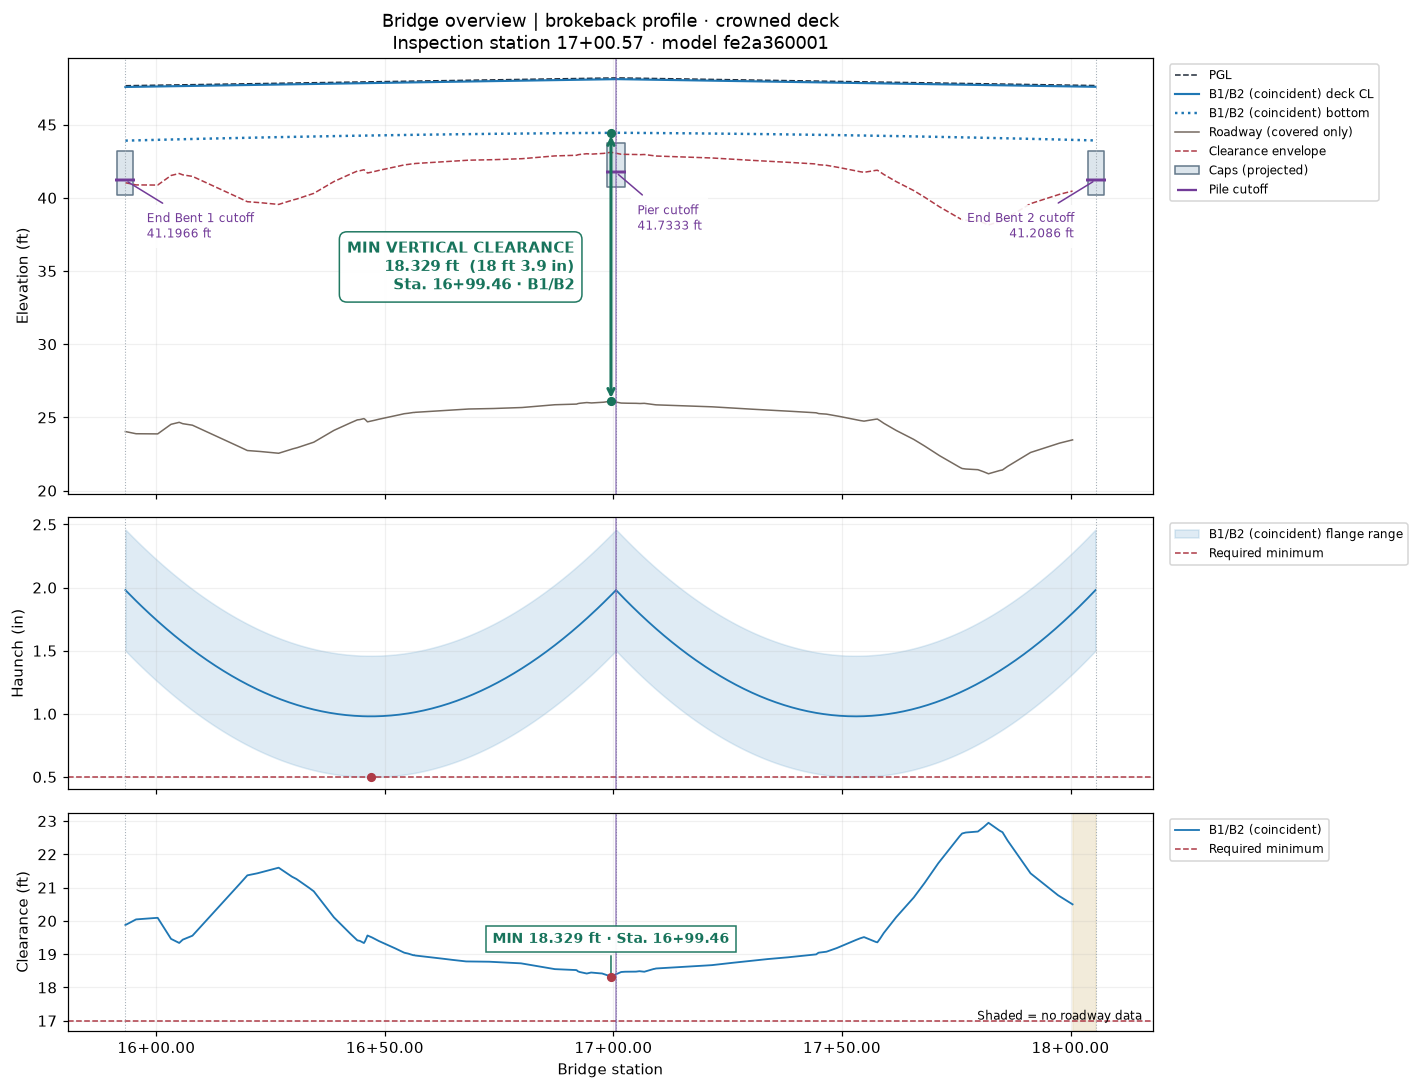

In [6]:
display(clearance_card(MODEL))
show_table(MODEL.summary(),'Bridge summary')
overview = longitudinal_figure(MODEL, MODEL.pier.get('station', MODEL.start))
display(overview)
plt.close(overview)


## 4. Shared station inspector and cross-section

One station slider/exact input drives all live views. Jump to the supports or span midpoints.
Profile and deck-mode selectors rebuild the geometry, all support schedules and quantities together;
invalid inputs leave the previous valid result visible with an error message.

The single cross-section renderer adds bearings, pedestals, cap and pile heads **at the pier and both end bents**.
Matching span ends are drawn once; differing ends receive separate views. Component colors are consistent.
Select a detail beam, toggle dense labels or expose individual flange lines. Expand the calculation trace
for equations instead of maintaining a separate verification notebook section.


In [7]:
dashboard = make_dashboard(CONFIG, MODEL)


**Static inspection snapshot** — captured from the Section 1 inputs, independent of widget rendering.


Beam,Offset (ft),Deck CL (ft),Beam top (ft),Beam bottom (ft),Camber (in),Haunch L (in),Haunch CL (in),Haunch R (in),Clearance (ft)
1,-4.292,48.112,47.447,44.447,0.000,1.500,1.980,2.460,18.394
2,4.292,48.112,47.447,44.447,0.000,2.460,1.980,1.500,18.394


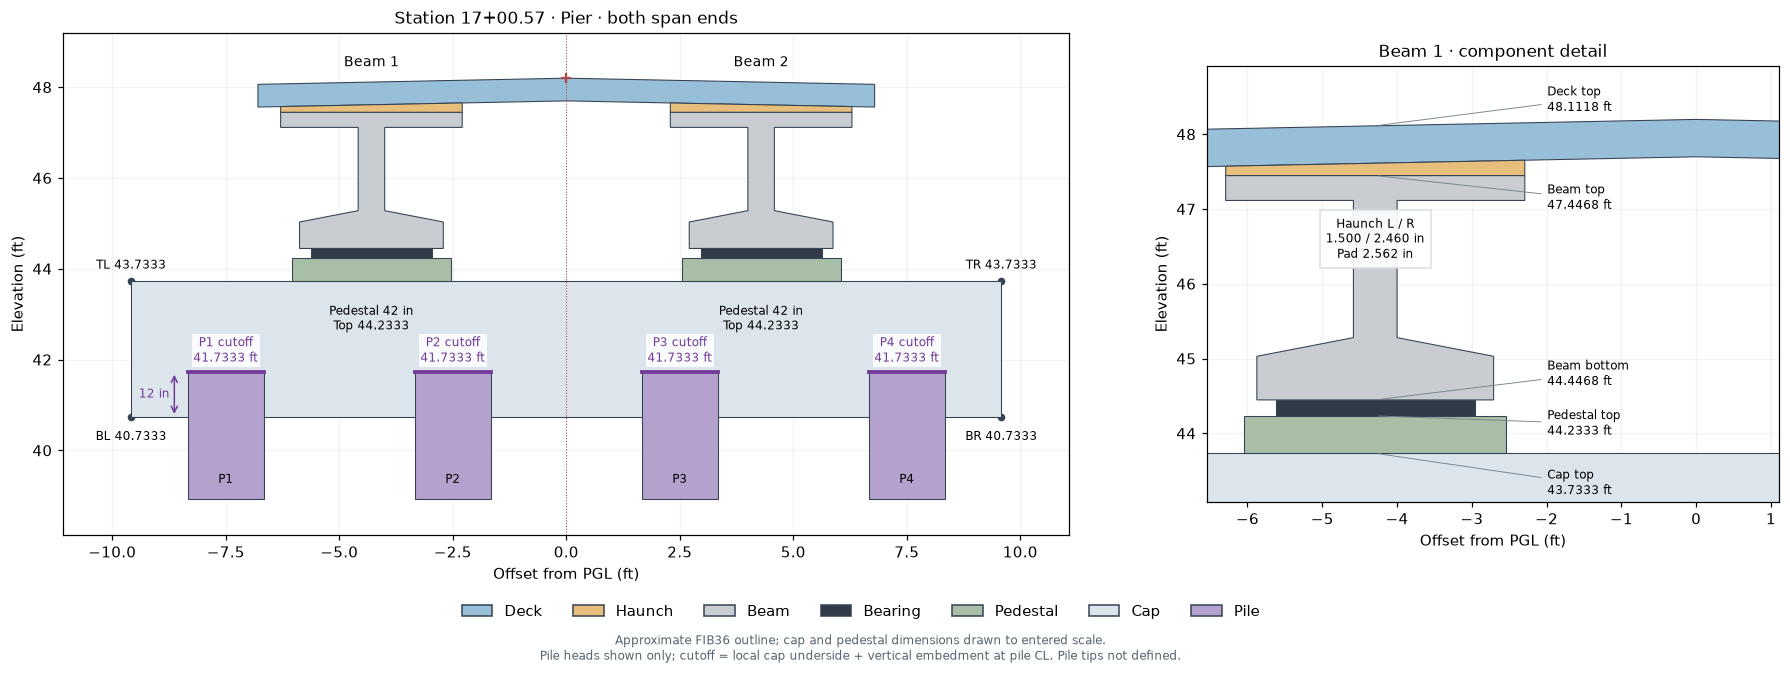

In [8]:
snapshot_station = MODEL.pier.get('station', MODEL.start)
show_table(MODEL.selected_table(snapshot_station), f'Selected-station beam schedule · {station_label(snapshot_station)}')
cross_section = section_figure(MODEL, snapshot_station)
display(cross_section)
plt.close(cross_section)
display(calculation_details(MODEL, snapshot_station))


## 5. Pier elevation schedule

Pedestal top = beam support bottom − 2-9/16-in Type F pad thickness.
Cap top follows a 6-in pedestal height at beam centerlines; cap underside is 36 in lower.
Pile cutoff = local cap underside + 12 in / 12. At the saved inputs all four piles have
cap underside **40.73325 ft** and cutoff **41.73325 ft**. These are project elevations;
the live schedule recomputes them from the current cap slope, depth and embedment.

The 42-in pedestal and 32-in bearing widths are modeled transversely.

Cap length is derived from the pile arrangement and shown with the resolved pile center offsets.
At the current inputs the cap is 19 ft 2 in × 4 ft × 3 ft, or 230 ft³ before local detailing deductions.
The cap/pile table is a geometry schedule and does not establish capacities or new analysis forces.

Identical span-end rows are grouped for display only. `MODEL.pier['seats']` retains both ends.
TL/TR/BR/BL are cap corners in transverse elevation. Physical fore/aft bearing offsets, pedestal
longitudinal seat grades, and local thickened slab ends remain outside this idealized support section.
The journal's 10-in longitudinal pad length and zero separate plate thickness are retained.


In [9]:
show_pier(MODEL)


Support,Beam,Offset (ft),Beam bottom (ft),Pad (in),Pedestal top (ft),Width (in),Pedestal height (in)
Both spans,1,-4.2917,44.4468,2.5625,44.2333,42.0000,6.0000
Both spans,2,4.2917,44.4468,2.5625,44.2333,42.0000,6.0000


Corner,Offset (ft),Elevation (ft)
TL,-9.5833,43.7333
TR,9.5833,43.7333
BR,9.5833,40.7333
BL,-9.5833,40.7333


Length (ft),Width (ft),Depth (ft),Pile spacing (ft),End pile face clearance (in),Cap volume (ft3)
19.1667,4.0000,3.0000,5.0000,15.0000,230.0000


Pile,Offset (ft),Diameter (in),Cap top (ft),Cap underside (ft),Embedment (in),Pile cutoff (ft)
1,-7.5000,20.0000,43.7333,40.7333,12.0000,41.7333
2,-2.5000,20.0000,43.7333,40.7333,12.0000,41.7333
3,2.5000,20.0000,43.7333,40.7333,12.0000,41.7333
4,7.5000,20.0000,43.7333,40.7333,12.0000,41.7333


## 6. End-bent elevation views

End Bent 1 is at the beginning of the bridge; End Bent 2 is at the end. Each view
uses its own beam support elevation and the project cap/bearing/pile geometry.
Select **End Bent 1** or **End Bent 2** in the live station inspector for the same
view with interactive profile/deck changes. The **End-bent schedules** tab contains
both sets of elevations. Short pile heads show embedment, not pile tips.

The 30-in longitudinal pedestal footprint and 12-in backwall thickness are listed
in the schedules. Backwall height and cheek-wall elevations remain undefined in
the source project data; their outlines are not drawn.


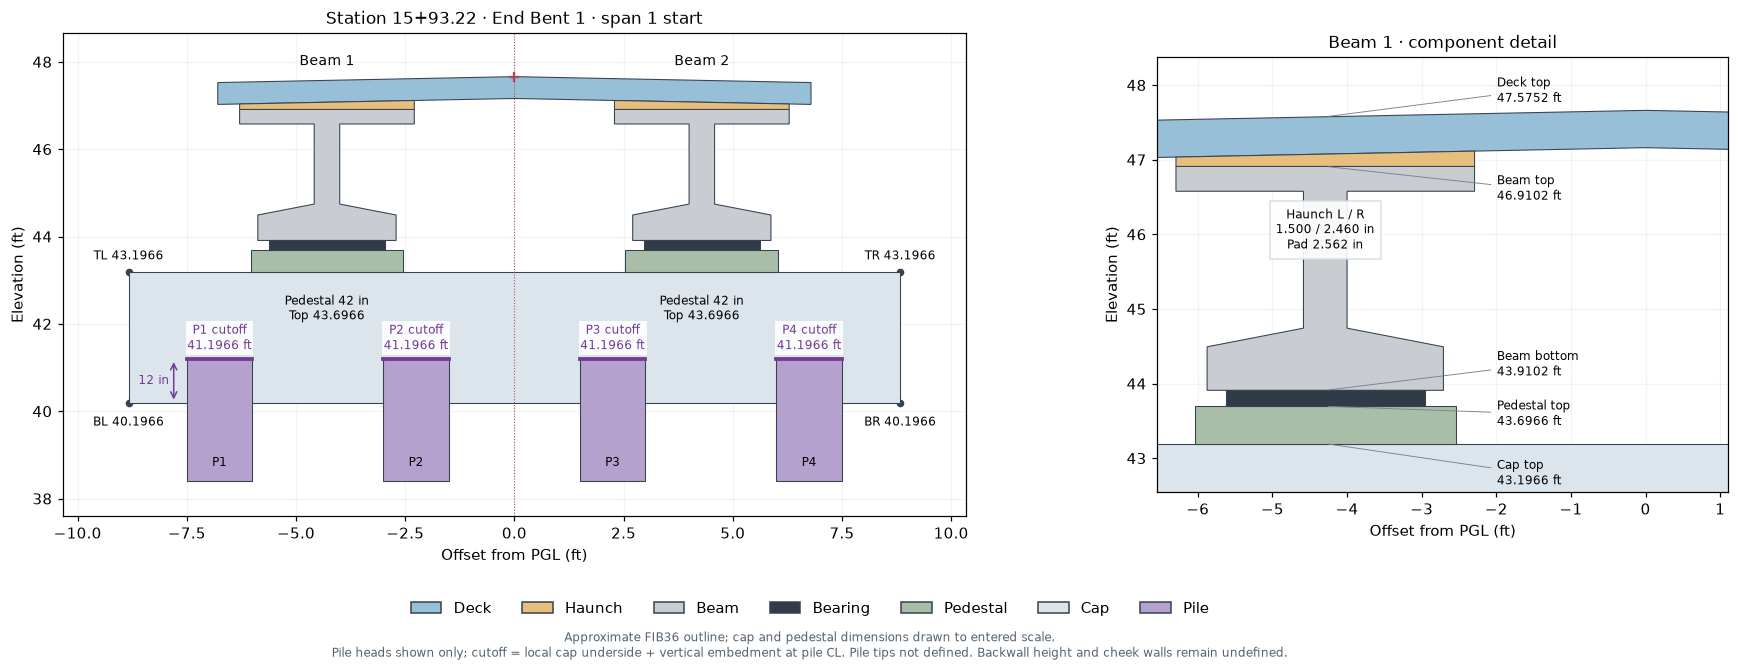

Span,Beam,Offset (ft),Beam bottom (ft),Pad (in),Pedestal top (ft),Width (in),Pedestal height (in)
1,1,-4.2917,43.9102,2.5625,43.6966,42.0000,6.0000
1,2,4.2917,43.9102,2.5625,43.6966,42.0000,6.0000


Corner,Offset (ft),Elevation (ft)
TL,-8.8333,43.1966
TR,8.8333,43.1966
BR,8.8333,40.1966
BL,-8.8333,40.1966


Pile,Offset (ft),Square pile width (in),Cap top (ft),Cap underside (ft),Embedment (in),Pile cutoff (ft)
1,-6.7500,18.0000,43.1966,40.1966,12.0000,41.1966
2,-2.2500,18.0000,43.1966,40.1966,12.0000,41.1966
3,2.2500,18.0000,43.1966,40.1966,12.0000,41.1966
4,6.7500,18.0000,43.1966,40.1966,12.0000,41.1966


Cap length (ft),Cap width (in),Cap depth (in),Pile spacing (in),End pile CL to cap end (in),Pedestal length (in),Backwall thickness (in),Bearing offset toward span (in)
17.667,42.000,36.000,54.000,25.000,30.000,12.000,3.000


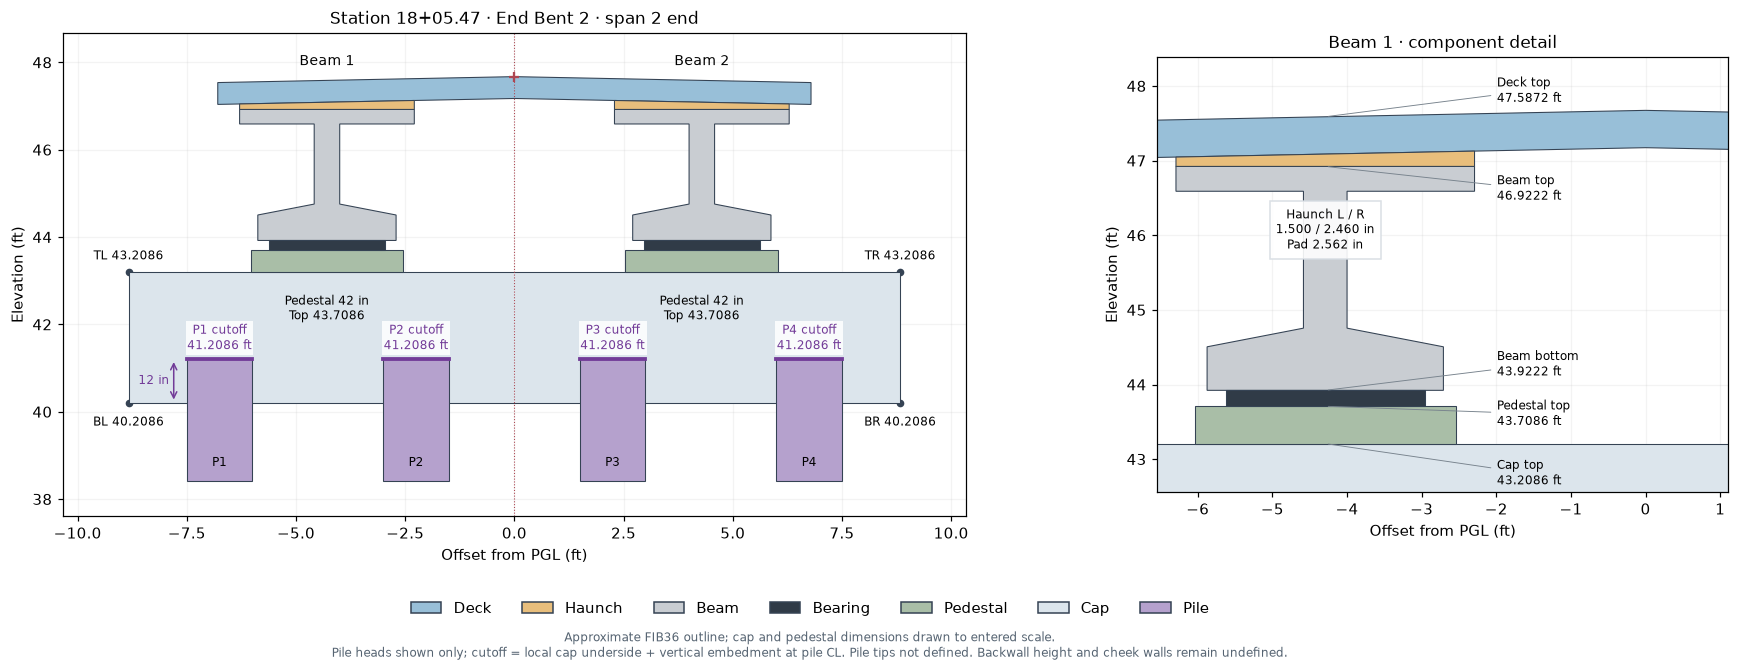

Span,Beam,Offset (ft),Beam bottom (ft),Pad (in),Pedestal top (ft),Width (in),Pedestal height (in)
2,1,-4.2917,43.9222,2.5625,43.7086,42.0000,6.0000
2,2,4.2917,43.9222,2.5625,43.7086,42.0000,6.0000


Corner,Offset (ft),Elevation (ft)
TL,-8.8333,43.2086
TR,8.8333,43.2086
BR,8.8333,40.2086
BL,-8.8333,40.2086


Pile,Offset (ft),Square pile width (in),Cap top (ft),Cap underside (ft),Embedment (in),Pile cutoff (ft)
1,-6.7500,18.0000,43.2086,40.2086,12.0000,41.2086
2,-2.2500,18.0000,43.2086,40.2086,12.0000,41.2086
3,2.2500,18.0000,43.2086,40.2086,12.0000,41.2086
4,6.7500,18.0000,43.2086,40.2086,12.0000,41.2086


Cap length (ft),Cap width (in),Cap depth (in),Pile spacing (in),End pile CL to cap end (in),Pedestal length (in),Backwall thickness (in),Bearing offset toward span (in)
17.667,42.000,36.000,54.000,25.000,30.000,12.000,3.000


In [10]:
for support in MODEL.end_bents:
    display(HTML(f'<h3>{support["name"]} · station {station_label(support["station"])}</h3>'))
    figure = section_figure(MODEL, support['station'])
    display(figure)
    plt.close(figure)
    show_end_bent(support)


## 7. Quantities and QC

Haunch volume integrates across the actual flange width, splitting crown crossings, then along each span
with intervals split at profile and slope breaks. It is a model quantity, not a claim of as-built accuracy.
The former “ballpark” duplicate is replaced by a closed-form camber integral where its assumptions apply.

The frozen comparison below guards the original support/pedestal elevations and volume for the baseline
inputs. General QC still runs after inputs change. The uncovered roadway tail remains “Not evaluated”;
this is not a full-bridge clearance certification or structural-capacity check.

Precision is retained internally; only readouts are rounded. Reusable full-precision tables:
`MODEL.quantity_table`, `MODEL.selected_table(station)`, `MODEL.pier['seats']`,
`MODEL.pier['corners']`, and `MODEL.pier['pile_elevations']`.


In [11]:
# @title Regression and model QC — no second geometry implementation
BASELINE = {'source_notebook': 'Bridge_Geo_2_Beam.ipynb',
 'source_sha256': 'ec338a90fc9f03cc1f6c93b6aca1789a67938b93c2163794b06147d474e826dd',
 'original_numerical_volume_cf': np.float64(185.83682346577982),
 'support_start_elev_ft': [43.91017, 44.446795],
 'support_end_elev_ft': [44.446795, 43.92217],
 'pier_corner_elev_ft': [43.95462833333333, 43.95462833333333, 37.95462833333333, 37.95462833333333],
 'pedestal_top_elev_ft': [44.28796166666667, 44.28796166666667, 44.28796166666667, 44.28796166666667],
 'configuration': {'profile': {'mode': 'brokeback',
                               'start_sta_ft': 1593.22,
                               'end_sta_ft': 1805.47,
                               'start_elev_ft': 47.661,
                               'end_elev_ft': 47.673,
                               'intersection_sta_ft': 1700.57,
                               'nominal_grade': 0.005,
                               'parabolic_grade_change': -0.01},
                   'deck': {'mode': 'crowned',
                            'width_ft': 13.583333333333334,
                            'center_offset_ft': 0.0,
                            'thickness_ft': 0.5,
                            'crown_slope': -0.02,
                            'uniform_slope': -0.02,
                            'transition_start_ft': 1603.22,
                            'transition_end_ft': 1643.22,
                            'slope_start': -0.02,
                            'slope_end': 0.04},
                   'beams': {'count': 2,
                             'spacing_ft': 8.583,
                             'first_offset_ft': None,
                             'gaps_ft': None,
                             'raise_in': 0.0,
                             'depth_ft': 3,
                             'top_flange_width_in': 48.0,
                             'minimum_haunch_in': 0.5},
                   'spans': [{'id': 1, 'start_ft': 1593.22, 'end_ft': 1700.57, 'camber_in': 1.0},
                             {'id': 2, 'start_ft': 1700.57, 'end_ft': 1805.47, 'camber_in': 1.0}],
                   'pier': {'station_ft': 1700.57,
                            'pad_height_in': 1.906,
                            'depth_ft': 6,
                            'length_ft': 29.5,
                            'minimum_pedestal_cl_in': 4,
                            'top_center_ft': None,
                            'center_offset_ft': 0.0,
                            'cross_slope': 0.0,
                            'pedestal_width_in': 36.0,
                            'pad_width_in': None}}}

def qc_checks(model):
    checks = []
    def check(name, ok, note):
        checks.append({'Check': name, 'Status': 'Pass' if ok else 'Fail', 'Basis': note})
    check('Profile endpoints', np.allclose(model.pgl([model.start,model.end]),[model.z0,model.z1],rtol=0,atol=1e-9),
          'Both entered endpoint elevations honored')
    check('Support continuity', np.allclose(model.spans.bottom_end_ft.to_numpy()[:-1],model.spans.bottom_start_ft.to_numpy()[1:],rtol=0,atol=1e-9),
          'Adjacent beam supports agree')
    check('Bridge-wide haunch', model.haunch_min >= model.minimum_haunch-1e-9,
          'All spans; flange edges, centerlines and crown crossings; polynomial extrema')
    at=model.evaluate(np.r_[model.spans.start_ft.to_numpy(),model.end])
    check('Zero support camber', np.allclose(at['camber'],0,rtol=0,atol=1e-9),'Camber is zero at span endpoints')
    seats=model.pier['seats']
    if not model.pier['missing']:
        check('Bearing stack closure', np.allclose(seats['Pedestal top (ft)']+seats['Pad (in)']/12,seats['Beam bottom (ft)'],rtol=0,atol=1e-9),
              'Pedestal top + pad = beam bottom')
    delta=model.quantity_table['Analytical difference (ft3)'].dropna()
    if len(delta):check('Independent quantity check', bool(np.all(np.abs(delta)<1e-7)), 'Closed-form integral of the camber parabola')
    if model.pier.get('pile_basis') is not None:
        p=model.pier;b=p['pile_basis'];xs=p['pile_layout']['Offset (ft)'].to_numpy()
        length=(b['count']-1)*b['spacing_ft']+b['diameter_ft']+2*b['end_clear_ft']
        cut=p['pile_elevations']
        if cut['Pile cutoff (ft)'].notna().all():
            check('Pile cutoff embedment',np.allclose(cut['Pile cutoff (ft)']-cut['Cap underside (ft)'],p['pile_embedment_ft'],rtol=0,atol=1e-9),
                  'Cutoff is vertically above the local cap underside at each pile centerline')
        else:
            checks.append({'Check':'Pile cutoff embedment','Status':'Not evaluated','Basis':'Cap elevation/depth is incomplete'})
        check('Pile-based cap length',abs(p['length']-length)<1e-9,'Centers plus diameter plus two pile-face clearances')
        edges=[xs[0]-b['diameter_ft']/2-(p['center']-p['length']/2),
               p['center']+p['length']/2-(xs[-1]+b['diameter_ft']/2)]
        check('End pile face clearances',np.allclose(edges,b['end_clear_ft'],rtol=0,atol=1e-9),'Both cap ends retain the entered face clearance')
    for support in model.end_bents:
        seats=support['seats'];piles=support['pile_elevations'];name=support['name']
        if support['missing']:
            checks.append({'Check':name+' geometry','Status':'Not evaluated','Basis':', '.join(support['missing'])})
            continue
        check(name+' bearing stack',np.allclose(seats['Pedestal top (ft)']+seats['Pad (in)']/12,seats['Beam bottom (ft)'],rtol=0,atol=1e-9),
              'Pedestal top + bearing thickness = beam bottom')
        check(name+' pile cutoff',np.allclose(piles['Pile cutoff (ft)']-piles['Cap underside (ft)'],support['pile_embedment_ft'],rtol=0,atol=1e-9),
              'Vertical embedment at each pile centerline')
    actual={k:v for k,v in model.cfg.items() if k not in ['roadway','evaluation']}
    if actual==BASELINE['configuration']:
        check('Original beam support elevations', np.allclose(model.spans.bottom_start_ft,BASELINE['support_start_elev_ft'],rtol=0,atol=1e-8)
              and np.allclose(model.spans.bottom_end_ft,BASELINE['support_end_elev_ft'],rtol=0,atol=1e-8),'Frozen original notebook snapshot')
        check('Original pier/pedestal elevations', np.allclose(model.pier['corners']['Elevation (ft)'],BASELINE['pier_corner_elev_ft'],rtol=0,atol=1e-8)
              and np.allclose(seats['Pedestal top (ft)'],BASELINE['pedestal_top_elev_ft'],rtol=0,atol=1e-8),'Frozen original notebook snapshot')
        check('Original quantity agreement', abs(model.quantity_table['Volume (ft3)'].sum()-BASELINE['original_numerical_volume_cf'])<.001,
              'Within 0.001 ft3 of former 1000-point trapezoidal estimate')
    else:
        checks.append({'Check':'Original snapshot comparison','Status':'Not evaluated','Basis':'Inputs differ from the saved baseline; general QC still applies'})
    return pd.DataFrame(checks)

show_quantities(MODEL)
show_table(qc_checks(MODEL),'Geometry and regression QC')
assert not (qc_checks(MODEL)['Status']=='Fail').any(), 'Resolve failed QC before using these results.'


Span,Beam,Volume (ft3),Volume (yd3),Min flange haunch (in),Station,Analytical difference (ft3)
1,1,46.9954,1.7406,0.5000,16+46.89,0.0000
1,2,46.9954,1.7406,0.5000,16+46.89,0.0000
2,1,45.9229,1.7008,0.5000,17+53.02,-0.0000
2,2,45.9229,1.7008,0.5000,17+53.02,-0.0000


Span,Volume (ft3),Volume (yd3)
1.0,93.9909,3.4811
2.0,91.8458,3.4017
BRIDGE TOTAL,185.8367,6.8828


Check,Status,Basis
Profile endpoints,Pass,Both entered endpoint elevations honored
Support continuity,Pass,Adjacent beam supports agree
Bridge-wide haunch,Pass,"All spans; flange edges, centerlines and crown crossings; polynomial extrema"
Zero support camber,Pass,Camber is zero at span endpoints
Bearing stack closure,Pass,Pedestal top + pad = beam bottom
Independent quantity check,Pass,Closed-form integral of the camber parabola
Pile cutoff embedment,Pass,Cutoff is vertically above the local cap underside at each pile centerline
Pile-based cap length,Pass,Centers plus diameter plus two pile-face clearances
End pile face clearances,Pass,Both cap ends retain the entered face clearance
End Bent 1 bearing stack,Pass,Pedestal top + bearing thickness = beam bottom
